<a href="https://colab.research.google.com/github/Masiania-bit/Maria-palander/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV о вулканах

**Что делаем:**

- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `data/volcano.csv` (2388 записей о вулканах)
- Переименовываем технические столбцы с URL Wikidata (volcano, country, mountainRange) в `*_url` (сохраняем для отладки)
- Переименовываем читаемые столбцы с постфиксом `Label` (volcanoLabel → volcano, countryLabel → country, mountainRangeLabel → mountainRange)
- Приводим числовое поле `elevation` к целочисленному типу `int`, заменяя пропуски на 0

**Результат:** чистая таблица `df` с полями:

- `volcano_url` — ссылка на объект Wikidata (для отладки)
- `country_url` — ссылка на страну в Wikidata
- `mountainRange_url` — ссылка на горную цепь в Wikidata
- `volcano` — название вулкана
- `elevation` — высота вулкана (метры)
- `country` — страна (если указана)
- `mountainRange` — горная цепь (если указана)
- `coord` — координаты в формате Wikidata (требует дополнительной обработки)

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных о вулканах

import os
import pandas as pd
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "MAsiania-bit"
repo = "Maria-palander"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с вулканами
df = pd.read_csv("data/volcano.csv")
print(f"📊 Загружено строк в датасете: {len(df)}\n")

# Шаг 3: Очистка данных
# Технические столбцы с URL переименовываем, добавляя суффикс "_url"
rename_dict = {}
if "volcano" in df.columns:
    rename_dict["volcano"] = "volcano_url"
if "country" in df.columns:
    rename_dict["country"] = "country_url"
if "mountainRange" in df.columns:
    rename_dict["mountainRange"] = "mountainRange_url"
df = df.rename(columns=rename_dict)

# Столбцы с читаемыми названиями (Label) переименовываем в основные имена
rename_dict_label = {}
if "volcanoLabel" in df.columns:
    rename_dict_label["volcanoLabel"] = "volcano"
if "countryLabel" in df.columns:
    rename_dict_label["countryLabel"] = "country"
if "mountainRangeLabel" in df.columns:
    rename_dict_label["mountainRangeLabel"] = "mountainRange"
df = df.rename(columns=rename_dict_label)

# Приводим высоту к целочисленному типу (заменяем некорректные значения на 0)
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce").fillna(0).astype(int)

print("✅ Данные очищены\n")

# Шаг 4: Краткий обзор датасета
print("📋 Структура данных о вулканах:")
print(f"   Столбцы: {', '.join(df.columns)}")
if "volcano" in df.columns:
    print(f"   Количество вулканов: {df['volcano'].nunique()}")
if "country" in df.columns:
    print(f"   Уникальных стран: {df['country'].nunique()}")
if "mountainRange" in df.columns:
    print(f"   Уникальных горных цепей: {df['mountainRange'].nunique()}")
print(f"   Диапазон высот: {df['elevation'].min()} — {df['elevation'].max()} м")
print(f"   Средняя высота: {df['elevation'].mean():.1f} м\n")

# Дополнительная информация о подводных вулканах и аномалиях
submarine = df[df["elevation"] < 0]
if len(submarine) > 0:
    print(f"🌊 Подводных вулканов (высота < 0): {len(submarine)}")
    print(f"   Самая глубокая точка: {submarine['elevation'].min()} м\n")

extreme = df[df["elevation"] > 8000]
if len(extreme) > 0:
    print(f"🌋 Вулканов выше 8000 м (возможно, марсианские): {len(extreme)}")
    print(extreme[["volcano", "elevation", "country", "mountainRange"]].head())

print(f"\n🔍 Первые 5 строк:\n{df.head()}")

/content/Maria-palander
✅ Репозиторий готов

📊 Загружено строк в датасете: 2388

✅ Данные очищены

📋 Структура данных о вулканах:
   Столбцы: volcano_url, volcano, elevation, country_url, country, coord, mountainRange_url, mountainRange
   Количество вулканов: 2134
   Уникальных стран: 86
   Уникальных горных цепей: 135
   Диапазон высот: -1400 — 18225 м
   Средняя высота: 1089.1 м

🌊 Подводных вулканов (высота < 0): 5
   Самая глубокая точка: -1400 м

🌋 Вулканов выше 8000 м (возможно, марсианские): 5
           volcano  elevation country        mountainRange
0  Гора Аскрийская      18225     NaN                  NaN
1     Mount Tehama       9239     США  California Cascades
2    Hayes Volcano       9147     США  Tordrillo Mountains
3  Cerro Nicholson       8282    Перу                  NaN
4  Isanotski Peaks       8106     США     Алеутский хребет

🔍 Первые 5 строк:
                                volcano_url          volcano  elevation  \
0    http://www.wikidata.org/entity/Q499164  

In [2]:
# 📥 [0] Клонирование репозитория и загрузка данных о вулканах

import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Шаг 1: Клонируем ваш репозиторий
github_user = "MAsiania-bit"
repo = "Maria-palander"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# ============================================
# ЧАСТЬ 1: ЗАГРУЗКА И ОЧИСТКА ВУЛКАНОВ
# ============================================

# Шаг 2: Загружаем CSV-файл с вулканами
df_volcano_raw = pd.read_csv("data/volcano.csv")
print(f"📊 Загружено строк в датасете вулканов: {len(df_volcano_raw)}")

# Шаг 3: Очистка данных о вулканах
# Переименовываем технические столбцы с URL
rename_dict = {}
if "volcano" in df_volcano_raw.columns:
    rename_dict["volcano"] = "volcano_url"
if "country" in df_volcano_raw.columns:
    rename_dict["country"] = "country_url"
if "mountainRange" in df_volcano_raw.columns:
    rename_dict["mountainRange"] = "mountainRange_url"
df_volcano_raw = df_volcano_raw.rename(columns=rename_dict)

# Переименовываем Label-столбцы в читаемые названия
rename_dict_label = {}
if "volcanoLabel" in df_volcano_raw.columns:
    rename_dict_label["volcanoLabel"] = "volcano"
if "countryLabel" in df_volcano_raw.columns:
    rename_dict_label["countryLabel"] = "country"
if "mountainRangeLabel" in df_volcano_raw.columns:
    rename_dict_label["mountainRangeLabel"] = "mountainRange"
df_volcano_raw = df_volcano_raw.rename(columns=rename_dict_label)

# Приводим высоту к числовому типу (оставляем NaN для пропусков)
df_volcano_raw["elevation"] = pd.to_numeric(df_volcano_raw["elevation"], errors="coerce")

# Извлечение координат
if "coord" in df_volcano_raw.columns:
    coords = df_volcano_raw["coord"].str.extract(r"Point\(([-\d.]+)\s+([-\d.]+)\)")
    df_volcano_raw["lon"] = pd.to_numeric(coords[0], errors="coerce")
    df_volcano_raw["lat"] = pd.to_numeric(coords[1], errors="coerce")

# Фильтрация марсианских объектов
df_volcano_raw["is_mars"] = (
    df_volcano_raw["coord"].str.contains("Q111", na=False) |
    (df_volcano_raw["lon"] > 180) |
    (df_volcano_raw["elevation"] > 7000)
)

# Создаём датафреймы для анализа
df_earth = df_volcano_raw[~df_volcano_raw["is_mars"]].copy()
df_earth_with_elev = df_earth[df_earth["elevation"].notna()].copy()

# Классификация высотных поясов
def classify_elevation(height):
    if pd.isna(height):
        return "нет данных"
    elif height < 0:
        return "подводные (< 0 м)"
    elif height < 1000:
        return "низкие (0–1000 м)"
    elif height < 3000:
        return "средние (1000–3000 м)"
    elif height < 6000:
        return "высокие (3000–6000 м)"
    else:
        return "экстремальные (> 6000 м)"

df_earth_with_elev["height_belt"] = df_earth_with_elev["elevation"].apply(classify_elevation)

print(f"\n🌍 Результат фильтрации вулканов:")
print(f"   • Всего объектов: {len(df_volcano_raw)}")
print(f"   • Марсианских объектов: {df_volcano_raw['is_mars'].sum()}")
print(f"   • Земных вулканов: {len(df_earth)}")
print(f"   • Земных вулканов с известной высотой: {len(df_earth_with_elev)}")

# ============================================
# ЧАСТЬ 2: ЗАГРУЗКА И ОЧИСТКА ГОРНЫХ СИСТЕМ
# ============================================

df_mr = pd.read_csv("data/mountain_range.csv")
print(f"\n📊 Загружено горных систем: {len(df_mr)}")

# Очистка столбцов горных систем
if "mrLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"mrLabel": "mountainRange"})
if "countryLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"countryLabel": "country"})
if "highPointLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"highPointLabel": "highPoint"})

# БЕЗОПАСНАЯ работа с partOf (без ошибок)
part_of_col = None
for col in df_mr.columns:
    if 'part' in col.lower():
        part_of_col = col
        break

if part_of_col:
    print(f"   Столбец иерархии: '{part_of_col}'")
    # Преобразуем в строку и считаем заполненность безопасно
    part_of_series = df_mr[part_of_col].astype(str)
    pct_filled = (part_of_series != 'nan').sum() / len(df_mr) * 100
    print(f"   Заполненность поля иерархии: {pct_filled:.1f}%")
else:
    print("   ⚠️ Столбец иерархии (partOf) не найден")

# Извлечение координат высших точек
if "coord" in df_mr.columns:
    coords_mr = df_mr["coord"].str.extract(r"Point\(([-\d.]+)\s+([-\d.]+)\)")
    df_mr["highPoint_lon"] = pd.to_numeric(coords_mr[0], errors="coerce")
    df_mr["highPoint_lat"] = pd.to_numeric(coords_mr[1], errors="coerce")

# ============================================
# ЧАСТЬ 3: ИТОГОВАЯ СВОДКА
# ============================================

print("\n" + "="*70)
print("📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ")
print("="*70)

print(f"\n✅ df_earth (земные вулканы): {len(df_earth)} записей")
print(f"   Столбцы: {', '.join(df_earth.columns)}")

print(f"\n✅ df_earth_with_elev (с известной высотой): {len(df_earth_with_elev)} записей")
if len(df_earth_with_elev) > 0:
    print(f"   Диапазон высот: {df_earth_with_elev['elevation'].min():.0f} — {df_earth_with_elev['elevation'].max():.0f} м")
    print(f"   Средняя высота: {df_earth_with_elev['elevation'].mean():.1f} м")

print(f"\n✅ df_mr (горные системы): {len(df_mr)} записей")
print(f"   Столбцы: {', '.join(df_mr.columns)}")

print("\n🔍 Пример данных df_earth (первые 3 строки):")
display_cols = [c for c in ["volcano", "elevation", "country", "lon", "lat"] if c in df_earth.columns]
if display_cols:
    print(df_earth[display_cols].head(3).to_string(index=False))

print("\n✅ Все датафреймы готовы для визуализаций!")

✅ Репозиторий готов

📊 Загружено строк в датасете вулканов: 2388

🌍 Результат фильтрации вулканов:
   • Всего объектов: 2388
   • Марсианских объектов: 24
   • Земных вулканов: 2364
   • Земных вулканов с известной высотой: 1350

📊 Загружено горных систем: 25570
   Столбец иерархии: 'partOf'
   Заполненность поля иерархии: 4.4%

📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ

✅ df_earth (земные вулканы): 2364 записей
   Столбцы: volcano_url, volcano, elevation, country_url, country, coord, mountainRange_url, mountainRange, lon, lat, is_mars

✅ df_earth_with_elev (с известной высотой): 1350 записей
   Диапазон высот: -1400 — 6903 м
   Средняя высота: 1851.0 м

✅ df_mr (горные системы): 25570 записей
   Столбцы: mr, mountainRange, country, country, coord, highPoint, highPoint, elevation, length, partOf, partOfLabel, highPoint_lon, highPoint_lat

🔍 Пример данных df_earth (первые 3 строки):
     volcano  elevation country         lon        lat
      Фопикд     6903.0     США -153.671944  58.770000
     Dots

In [3]:
# ============================================
# БИБЛИОТЕКИ ДЛЯ ВИЗУАЛИЗАЦИЙ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

print("🎨 Библиотеки загружены. Начинаем визуализацию...\n")
print(f"📊 Данные для анализа:")
print(f"   • Земные вулканы: {len(df_earth):,}")
print(f"   • С известной высотой: {len(df_earth_with_elev):,}")
print(f"   • Горные системы: {len(df_mr):,}\n")

🎨 Библиотеки загружены. Начинаем визуализацию...

📊 Данные для анализа:
   • Земные вулканы: 2,364
   • С известной высотой: 1,350
   • Горные системы: 25,570



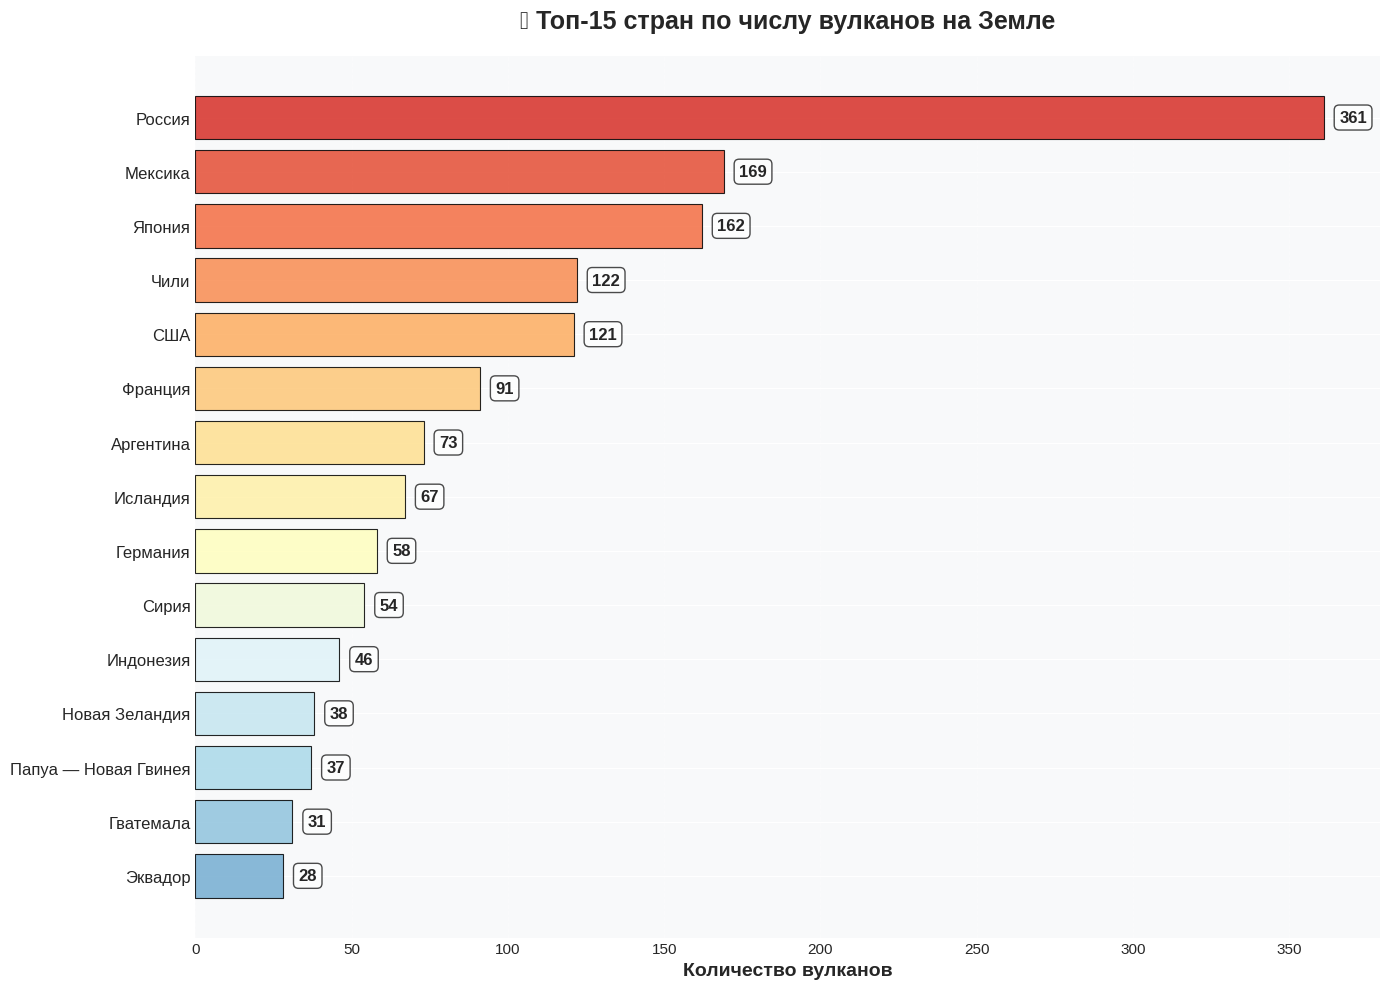

In [4]:
# Визуализация 1: Топ стран
fig, ax = plt.subplots(figsize=(14, 10))

top_countries = df_earth['country'].value_counts().head(15).sort_values()

# Создаём градиент цветов
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(top_countries)))

bars = ax.barh(top_countries.index, top_countries.values,
               color=colors, edgecolor='black', linewidth=0.8,
               alpha=0.85)

ax.set_xlabel('Количество вулканов', fontsize=14, fontweight='bold')
ax.set_title('🌋 Топ-15 стран по числу вулканов на Земле', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения на концах баров
for i, (bar, val) in enumerate(zip(bars, top_countries.values)):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

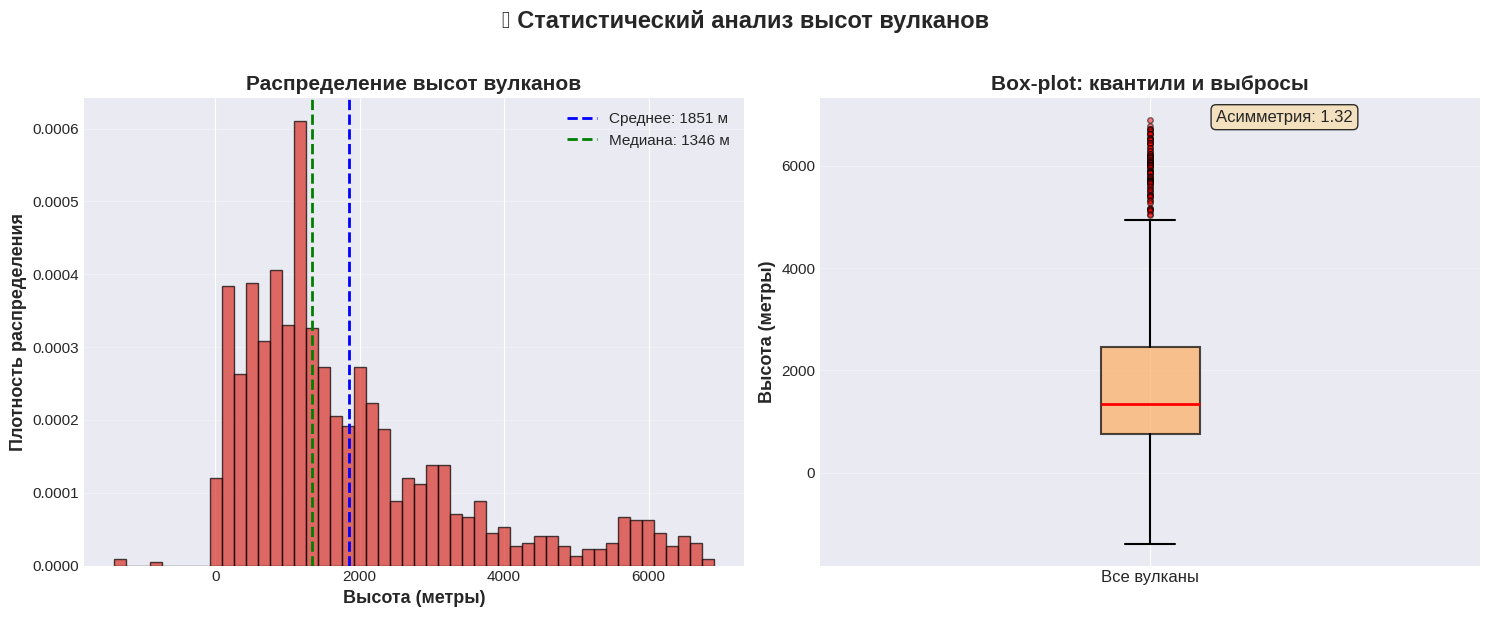

In [5]:
# Визуализация 2: Гистограмма и box plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма
ax1.hist(df_earth_with_elev['elevation'], bins=50, color='#d73027',
         edgecolor='black', alpha=0.7, density=True)
ax1.set_xlabel('Высота (метры)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Плотность распределения', fontsize=13, fontweight='bold')
ax1.set_title('Распределение высот вулканов', fontsize=15, fontweight='bold')

# Линии среднего и медианы
mean_val = df_earth_with_elev['elevation'].mean()
median_val = df_earth_with_elev['elevation'].median()
ax1.axvline(mean_val, color='blue', linestyle='--', linewidth=2,
            label=f'Среднее: {mean_val:.0f} м')
ax1.axvline(median_val, color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {median_val:.0f} м')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(alpha=0.3, axis='y')

# Box plot
box = ax2.boxplot(df_earth_with_elev['elevation'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#fdae61', linewidth=1.5, alpha=0.7),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   medianprops=dict(linewidth=2, color='red'),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
ax2.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax2.set_title('Box-plot: квантили и выбросы', fontsize=15, fontweight='bold')
ax2.set_xticklabels(['Все вулканы'], fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Добавляем статистику
skewness = df_earth_with_elev['elevation'].skew()
ax2.text(0.6, 0.95, f'Асимметрия: {skewness:.2f}', transform=ax2.transAxes,
         fontsize=12, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.suptitle('📏 Статистический анализ высот вулканов', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

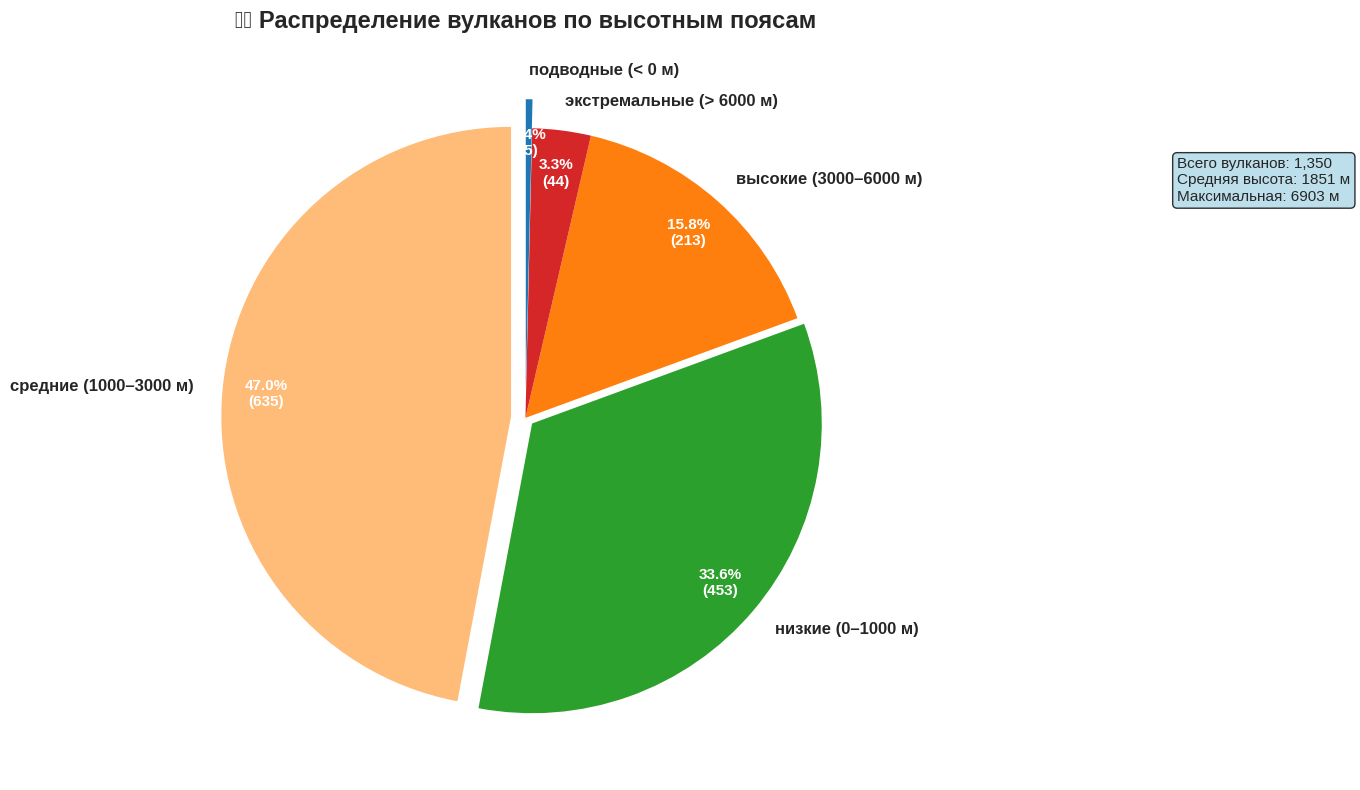

In [6]:
# Визуализация 3: Круговая диаграмма высотных поясов
fig, ax = plt.subplots(figsize=(12, 8))

belt_counts = df_earth_with_elev['height_belt'].value_counts()

# Цветовая схема по поясам
colors_belt = {
    'подводные (< 0 м)': '#1f77b4',
    'низкие (0–1000 м)': '#2ca02c',
    'средние (1000–3000 м)': '#ffbb78',
    'высокие (3000–6000 м)': '#ff7f0e',
    'экстремальные (> 6000 м)': '#d62728'
}
colors_list = [colors_belt[belt] for belt in belt_counts.index]

wedges, texts, autotexts = ax.pie(belt_counts.values,
                                    labels=belt_counts.index,
                                    autopct=lambda pct: f'{pct:.1f}%\n({pct/100*sum(belt_counts.values):.0f})',
                                    colors=colors_list,
                                    startangle=90,
                                    explode=(0.05, 0.03, 0, 0, 0.1),
                                    textprops={'fontsize': 12},
                                    pctdistance=0.85)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title('🏔️ Распределение вулканов по высотным поясам', fontsize=17, fontweight='bold', pad=20)

# Добавляем легенду с пояснениями
legend_text = [
    f"Всего вулканов: {sum(belt_counts.values):,}",
    f"Средняя высота: {df_earth_with_elev['elevation'].mean():.0f} м",
    f"Максимальная: {df_earth_with_elev['elevation'].max():.0f} м"
]
ax.text(1.4, 0.8, '\n'.join(legend_text), transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

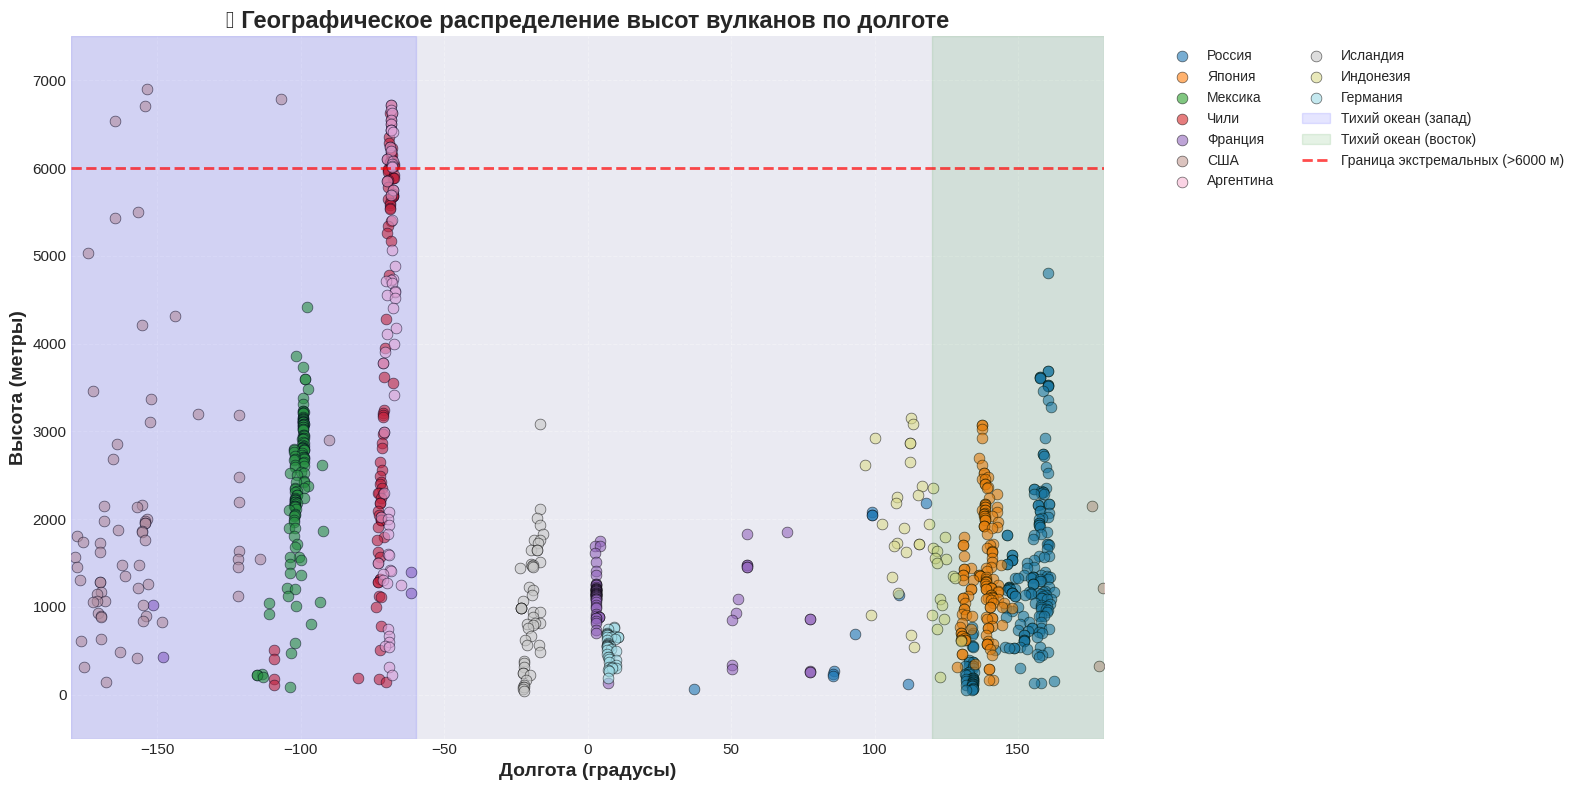

In [7]:
# Визуализация 4: Scatter plot высота vs долгота с цветом по странам
fig, ax = plt.subplots(figsize=(16, 8))

# Топ-10 стран для цветового кодирования
top10_countries = df_earth_with_elev['country'].value_counts().head(10).index
df_top10 = df_earth_with_elev[df_earth_with_elev['country'].isin(top10_countries)]

# Цветовая карта
colors = plt.cm.tab20(np.linspace(0, 1, len(top10_countries)))
country_color = {country: colors[i] for i, country in enumerate(top10_countries)}

for country in top10_countries:
    subset = df_top10[df_top10['country'] == country]
    ax.scatter(subset['lon'], subset['elevation'],
               label=country, alpha=0.6, s=60,
               color=country_color[country], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Долгота (градусы)', fontsize=14, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🌍 Географическое распределение высот вулканов по долготе', fontsize=17, fontweight='bold')

# Аннотации ключевых регионов
ax.axvspan(-180, -60, alpha=0.1, color='blue', label='Тихий океан (запад)')
ax.axvspan(120, 180, alpha=0.1, color='green', label='Тихий океан (восток)')
ax.axhline(y=6000, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Граница экстремальных (>6000 м)')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=2)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(-180, 180)
ax.set_ylim(-500, 7500)

plt.tight_layout()
plt.show()

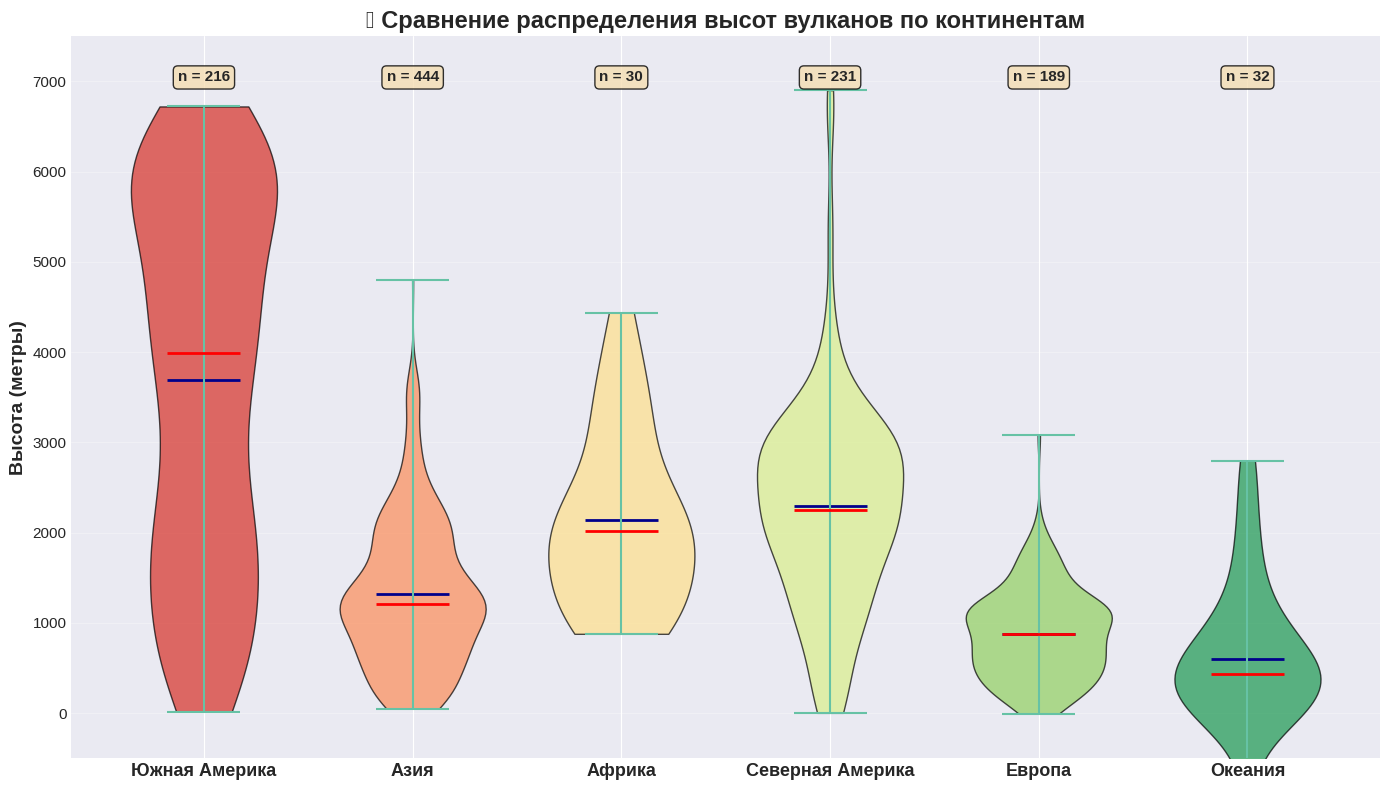

In [8]:
# Визуализация 5: Violin plot по континентам
# Создаём маппинг стран на континенты
continent_map = {
    'Россия': 'Азия', 'Китай': 'Азия', 'Япония': 'Азия', 'Индонезия': 'Азия',
    'Индия': 'Азия', 'Филиппины': 'Азия', 'Папуа — Новая Гвинея': 'Океания',
    'Новая Зеландия': 'Океания', 'США': 'Северная Америка', 'Мексика': 'Северная Америка',
    'Канада': 'Северная Америка', 'Гватемала': 'Северная Америка', 'Коста-Рика': 'Северная Америка',
    'Чили': 'Южная Америка', 'Аргентина': 'Южная Америка', 'Перу': 'Южная Америка',
    'Эквадор': 'Южная Америка', 'Колумбия': 'Южная Америка', 'Франция': 'Европа',
    'Германия': 'Европа', 'Исландия': 'Европа', 'Италия': 'Европа', 'Греция': 'Европа',
    'Сирия': 'Азия', 'Кения': 'Африка', 'Танзания': 'Африка', 'Камерун': 'Африка',
    'Эфиопия': 'Африка', 'Демократическая Республика Конго': 'Африка'
}

df_earth_with_elev['continent'] = df_earth_with_elev['country'].map(continent_map)
df_continent = df_earth_with_elev.dropna(subset=['continent'])

fig, ax = plt.subplots(figsize=(14, 8))

order = ['Южная Америка', 'Азия', 'Африка', 'Северная Америка', 'Европа', 'Океания']
data_by_continent = [df_continent[df_continent['continent'] == c]['elevation'].dropna() for c in order]

# Создаём violin plot
parts = ax.violinplot(data_by_continent, positions=range(len(order)),
                       showmeans=True, showmedians=True, widths=0.7)

# Настройка цветов
colors_violin = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

parts['cmeans'].set_color('darkblue')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('red')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🎻 Сравнение распределения высот вулканов по континентам', fontsize=17, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем количество наблюдений
for i, cont in enumerate(order):
    n_volcanoes = len(data_by_continent[i])
    ax.text(i, 7000, f'n = {n_volcanoes}', ha='center', fontsize=11,
            fontweight='bold', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [10]:
# 📊 ВИЗУАЛИЗАЦИЯ 6: Интерактивная карта вулканов (исправленная)

# Подготовка данных: исключаем подводные вулканы для размера (или используем логи)
df_map = df_earth_with_elev.dropna(subset=['lat', 'lon']).copy()

# Вариант 1: Исключаем подводные вулканы для карты (чтобы size был положительным)
df_map_positive = df_map[df_map['elevation'] > 0].copy()
sample_size = min(800, len(df_map_positive))
df_map_sample = df_map_positive.sample(n=sample_size, random_state=42)

# Вариант 2: Используем логарифмический размер для всех вулканов (включая подводные)
# Создаём нормализованный размер (смещаем на +1500, чтобы все значения были >0)
df_map['size_normalized'] = df_map['elevation'] + 1500  # минимальное -1400 + 1500 = 100 > 0
df_map['size_normalized'] = df_map['size_normalized'].clip(lower=50, upper=500)  # ограничиваем размер

# Выбираем метод (рекомендую метод 1)
use_method = 1  # 1 = только положительные высоты, 2 = все с нормализацией

if use_method == 1:
    df_plot = df_map_sample
    size_col = 'elevation'
    size_max = 20
else:
    df_plot = df_map
    size_col = 'size_normalized'
    size_max = 25

# Создаём интерактивную карту
fig = px.scatter_geo(df_plot,
                      lat='lat',
                      lon='lon',
                      color='height_belt',
                      hover_name='volcano',
                      hover_data={
                          'elevation': ':,.0f',
                          'country': True,
                          'lat': False,
                          'lon': False,
                          'height_belt': True
                      },
                      size=size_col,
                      size_max=size_max,
                      color_discrete_map=colors_belt,
                      title='🌋 Интерактивная карта вулканов Земли (без подводных)',
                      projection='natural earth',
                      template='plotly_dark')

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    legend_title_text='Высотный пояс',
    legend_title_font_size=14,
    legend_font_size=12,
    width=1200,
    height=700
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor='white',
    showland=True,
    landcolor='rgb(40, 40, 40)',
    showocean=True,
    oceancolor='rgb(20, 30, 50)',
    showcountries=True,
    countrycolor='rgba(255, 255, 255, 0.3)'
)

fig.show()

print(f"📊 На карте отображено {len(df_plot)} вулканов")
print(f"   (исключены подводные вулканы с отрицательной высотой)")

# Альтернативный вариант: карта плотности (если scatter_geo не подходит)
print("\n💡 Альтернатива: Карта плотности вулканов")

📊 На карте отображено 800 вулканов
   (исключены подводные вулканы с отрицательной высотой)

💡 Альтернатива: Карта плотности вулканов


In [11]:
# Визуализация 7: Treemap горных систем
# Агрегируем данные о горных системах
mountain_counts = df_earth['mountainRange'].value_counts().head(20).reset_index()
mountain_counts.columns = ['mountainRange', 'count']
mountain_counts['percentage'] = (mountain_counts['count'] / mountain_counts['count'].sum() * 100).round(1)

# Создаём treemap с plotly
fig = px.treemap(mountain_counts,
                  path=['mountainRange'],
                  values='count',
                  color='count',
                  color_continuous_scale='Reds',
                  title='⛰️ Горные системы с наибольшим числом вулканов',
                  hover_data={'percentage': ':.1f%', 'count': ':,.0f'},
                  width=1100,
                  height=650)

fig.update_traces(
    textinfo="label+value+percent root",
    textfont_size=14,
    textfont_color='white',
    marker=dict(line=dict(width=2, color='white')),
    hovertemplate='<b>%{label}</b><br>Вулканов: %{value}<br>Доля: %{percentRoot:.1f}%<extra></extra>'
)

fig.update_layout(
    title_font_size=18,
    title_font_weight='bold',
    coloraxis_colorbar_title_text='Количество вулканов'
)

fig.show()

In [13]:
# ============================================
# ГЕОГРАФИЧЕСКИЕ ВИЗУАЛИЗАЦИИ (ИСПРАВЛЕННЫЕ)
# ============================================
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("🗺️ Создаём географические визуализации...\n")

# Словарь перевода стран с русского на английский
country_translation = {
    'Россия': 'Russia',
    'США': 'United States',
    'Япония': 'Japan',
    'Индонезия': 'Indonesia',
    'Мексика': 'Mexico',
    'Чили': 'Chile',
    'Аргентина': 'Argentina',
    'Франция': 'France',
    'Германия': 'Germany',
    'Исландия': 'Iceland',
    'Сирия': 'Syria',
    'Новая Зеландия': 'New Zealand',
    'Папуа — Новая Гвинея': 'Papua New Guinea',
    'Гватемала': 'Guatemala',
    'Эквадор': 'Ecuador',
    'Перу': 'Peru',
    'Колумбия': 'Colombia',
    'Италия': 'Italy',
    'Греция': 'Greece',
    'Кения': 'Kenya',
    'Танзания': 'Tanzania',
    'Камерун': 'Cameroon',
    'Эфиопия': 'Ethiopia',
    'Филиппины': 'Philippines',
    'Индия': 'India',
    'Канада': 'Canada',
    'Китай': 'China'
}

# Добавляем английские названия в датафрейм
df_earth['country_en'] = df_earth['country'].map(country_translation)
df_earth_with_elev['country_en'] = df_earth_with_elev['country'].map(country_translation)

print(f"📊 Данные для карт:")
print(f"   • Вулканов с координатами: {df_earth['lat'].notna().sum():,}")
print(f"   • Стран с распознанными названиями: {df_earth['country_en'].notna().sum():,}\n")

🗺️ Создаём географические визуализации...

📊 Данные для карт:
   • Вулканов с координатами: 2,314
   • Стран с распознанными названиями: 1,605



In [16]:
# ============================================
# ГЕОГРАФИЧЕСКИЕ ВИЗУАЛИЗАЦИИ (ПОЛНОСТЬЮ ИСПРАВЛЕННЫЕ)
# ============================================
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("🗺️ Создаём географические визуализации...\n")

# Словарь перевода стран с русского на английский
country_translation = {
    'Россия': 'Russia',
    'США': 'United States',
    'Япония': 'Japan',
    'Индонезия': 'Indonesia',
    'Мексика': 'Mexico',
    'Чили': 'Chile',
    'Аргентина': 'Argentina',
    'Франция': 'France',
    'Германия': 'Germany',
    'Исландия': 'Iceland',
    'Сирия': 'Syria',
    'Новая Зеландия': 'New Zealand',
    'Папуа — Новая Гвинея': 'Papua New Guinea',
    'Гватемала': 'Guatemala',
    'Эквадор': 'Ecuador',
    'Перу': 'Peru',
    'Колумбия': 'Colombia',
    'Италия': 'Italy',
    'Греция': 'Greece',
    'Кения': 'Kenya',
    'Танзания': 'Tanzania',
    'Камерун': 'Cameroon',
    'Эфиопия': 'Ethiopia',
    'Филиппины': 'Philippines',
    'Индия': 'India',
    'Канада': 'Canada',
    'Китай': 'China'
}

# Добавляем английские названия в датафрейм
df_earth['country_en'] = df_earth['country'].map(country_translation)
df_earth_with_elev['country_en'] = df_earth_with_elev['country'].map(country_translation)

print(f"📊 Данные для карт:")
print(f"   • Вулканов с координатами: {df_earth['lat'].notna().sum():,}")
print(f"   • Стран с распознанными названиями: {df_earth['country_en'].notna().sum():,}\n")

🗺️ Создаём географические визуализации...

📊 Данные для карт:
   • Вулканов с координатами: 2,314
   • Стран с распознанными названиями: 1,605



In [17]:
# Карта 1: Choropleth map - количество вулканов по странам
country_counts = df_earth[df_earth['country_en'].notna()]['country_en'].value_counts().reset_index()
country_counts.columns = ['country', 'volcano_count']

# Добавляем среднюю и максимальную высоту
country_elevation = df_earth_with_elev.groupby('country_en')['elevation'].agg(['mean', 'max']).reset_index()
country_elevation.columns = ['country', 'avg_elevation', 'max_elevation']

country_stats = country_counts.merge(country_elevation, on='country', how='left')

# Добавляем русские названия
rus_names = {v: k for k, v in country_translation.items()}
country_stats['country_ru'] = country_stats['country'].map(rus_names)

print("Топ-10 стран по числу вулканов:")
print(country_stats.head(10))
print()

fig1 = px.choropleth(country_stats,
                     locations='country',
                     locationmode='country names',
                     color='volcano_count',
                     hover_name='country_ru',
                     hover_data={
                         'volcano_count': ':.0f',
                         'avg_elevation': ':.0f м',
                         'max_elevation': ':.0f м'
                     },
                     color_continuous_scale='Reds',
                     title='🌋 Количество вулканов по странам мира',
                     template='plotly_dark')

fig1.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    geo=dict(
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='rgb(50, 50, 50)',
        showocean=True,
        oceancolor='rgb(20, 30, 50)',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(title="Количество вулканов"),
    width=1200,
    height=700
)

fig1.show()
print("💡 ИНСАЙТ: Россия, США, Япония и Индонезия — главные вулканические державы мира\n")

Топ-10 стран по числу вулканов:
         country  volcano_count  avg_elevation  max_elevation country_ru
0         Russia            361    1234.608889         4800.0     Россия
1         Mexico            169    2413.719697         4420.0    Мексика
2          Japan            162    1402.960604         3067.0     Япония
3          Chile            122    3879.019608         6723.0       Чили
4  United States            121    2120.314085         6903.0        США
5         France             91    1089.405063         1850.0    Франция
6      Argentina             73    3842.883333         6723.0  Аргентина
7        Iceland             67    1011.520000         3081.0   Исландия
8        Germany             58     528.007317          773.0   Германия
9          Syria             54    1081.700000         1226.0      Сирия



💡 ИНСАЙТ: Россия, США, Япония и Индонезия — главные вулканические державы мира



In [18]:
# Карта 2: Scatter map - ТОЛЬКО вулканы с высотой > 0 (исключаем подводные)
df_map = df_earth_with_elev.dropna(subset=['lat', 'lon', 'elevation', 'country_en']).copy()
df_map = df_map[df_map['elevation'] > 0]  # Ключевое исправление!

print(f"   • Вулканов с положительной высотой для карты: {len(df_map)}")

fig2 = px.scatter_geo(df_map,
                       lat='lat',
                       lon='lon',
                       color='elevation',
                       size='elevation',
                       size_max=12,
                       hover_name='volcano',
                       hover_data={
                           'elevation': ':.0f м',
                           'country': True,
                           'mountainRange': True
                       },
                       color_continuous_scale='Viridis',
                       title='🗺️ Вулканы мира (высота > 0 м)',
                       projection='natural earth',
                       template='plotly_dark')

fig2.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    width=1200,
    height=700
)

fig2.update_geos(
    showcoastlines=True,
    coastlinecolor='white',
    showland=True,
    landcolor='rgb(40, 40, 40)',
    showocean=True,
    oceancolor='rgb(20, 30, 50)',
    showcountries=True,
    countrycolor='rgba(255, 255, 255, 0.3)'
)

fig2.show()
print("💡 ИНСАЙТ: Чётко видно Тихоокеанское огненное кольцо и концентрацию самых высоких вулканов в Андах\n")

   • Вулканов с положительной высотой для карты: 1123


💡 ИНСАЙТ: Чётко видно Тихоокеанское огненное кольцо и концентрацию самых высоких вулканов в Андах



In [19]:
# Карта 3: Density map - тепловая карта плотности (работает с любыми координатами)
df_density = df_earth.dropna(subset=['lat', 'lon']).copy()

fig3 = px.density_mapbox(df_density,
                          lat='lat',
                          lon='lon',
                          radius=15,
                          center=dict(lat=20, lon=0),
                          zoom=1,
                          mapbox_style="carto-darkmatter",
                          title='🔥 Тепловая карта плотности вулканов Земли',
                          opacity=0.7,
                          hover_data={'volcano': True, 'country': True})

fig3.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    coloraxis_colorbar=dict(title="Плотность"),
    width=1200,
    height=700
)

fig3.show()
print("💡 ИНСАЙТ: Максимальная плотность — Камчатка, Япония, Анды и Кордильеры\n")

💡 ИНСАЙТ: Максимальная плотность — Камчатка, Япония, Анды и Кордильеры



In [20]:
# Карта 4: Только высокие вулканы (>3000 м)
df_high = df_earth_with_elev[df_earth_with_elev['elevation'] > 3000].dropna(subset=['lat', 'lon']).copy()
df_high['height_category'] = pd.cut(df_high['elevation'],
                                     bins=[3000, 4500, 6000, 7000],
                                     labels=['3000-4500 м', '4500-6000 м', '>6000 м'])

fig4 = px.scatter_geo(df_high,
                       lat='lat',
                       lon='lon',
                       color='height_category',
                       size='elevation',
                       size_max=15,
                       hover_name='volcano',
                       hover_data={'elevation': ':.0f м', 'country': True},
                       color_discrete_sequence=['#ffbb78', '#ff7f0e', '#d62728'],
                       title='⛰️ Высокогорные вулканы (>3000 м)',
                       projection='natural earth',
                       template='plotly_white')

fig4.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    width=1200,
    height=700
)

fig4.update_geos(
    showcoastlines=True,
    coastlinecolor='gray',
    showland=True,
    landcolor='rgb(240, 240, 240)',
    showocean=True,
    oceancolor='rgb(200, 220, 240)'
)

fig4.show()
print("💡 ИНСАЙТ: Экстремальные вулканы (>6000 м) сконцентрированы исключительно в Андах\n")

💡 ИНСАЙТ: Экстремальные вулканы (>6000 м) сконцентрированы исключительно в Андах



In [21]:
# Карта 5: Подводные вулканы (высота < 0)
df_submarine = df_earth_with_elev[df_earth_with_elev['elevation'] < 0].dropna(subset=['lat', 'lon']).copy()

if len(df_submarine) > 0:
    # Для подводных используем фиксированный размер (нельзя отрицательный size)
    fig5 = px.scatter_geo(df_submarine,
                           lat='lat',
                           lon='lon',
                           color='elevation',
                           size_max=10,
                           hover_name='volcano',
                           hover_data={'elevation': ':.0f м', 'country': True},
                           color_continuous_scale='Blues',
                           title='🌊 Подводные вулканы (высота ниже уровня моря)',
                           projection='natural earth',
                           template='plotly_dark')

    fig5.update_traces(marker=dict(size=8))  # Фиксированный размер

    fig5.update_layout(
        title_font_size=20,
        title_font_weight='bold',
        width=1200,
        height=700
    )

    fig5.show()
    print(f"💡 ИНСАЙТ: Обнаружено {len(df_submarine)} подводных вулканов, самый глубокий: {df_submarine['elevation'].min():.0f} м\n")
else:
    print("⚠️ Подводных вулканов с координатами не найдено\n")

💡 ИНСАЙТ: Обнаружено 5 подводных вулканов, самый глубокий: -1400 м



In [22]:
# Бонус: 3D глобус (только положительные высоты)
df_globe = df_earth_with_elev[df_earth_with_elev['elevation'] > 0].dropna(subset=['lat', 'lon']).copy()
df_globe = df_globe.sample(n=min(500, len(df_globe)), random_state=42)

fig6 = go.Figure()

fig6.add_trace(go.Scattergeo(
    lon=df_globe['lon'],
    lat=df_globe['lat'],
    mode='markers',
    marker=dict(
        size=df_globe['elevation'] / 200,
        color=df_globe['elevation'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Высота (м)"),
        line=dict(width=0.5, color='white')
    ),
    text=df_globe['volcano'],
    hoverinfo='text',
    name='Вулканы'
))

fig6.update_layout(
    title=dict(text='🌍 3D Глобус вулканов Земли', font=dict(size=20), x=0.5),
    geo=dict(
        projection_type='orthographic',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='gray',
        showocean=True,
        oceancolor='rgb(150, 200, 240)'
    ),
    width=1000,
    height=700
)

fig6.show()
print("💡 ИНСАЙТ: 3D-глобус наглядно показывает циркум-тихоокеанское распределение вулканов\n")

💡 ИНСАЙТ: 3D-глобус наглядно показывает циркум-тихоокеанское распределение вулканов



In [23]:
# ============================================
# БИБЛИОТЕКИ ДЛЯ ПРОДВИНУТОГО АНАЛИЗА
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("🔍 Начинаем поиск скрытых паттернов...\n")
print(f"📊 Размер данных для анализа:")
print(f"   • Вулканов: {len(df_earth):,}")
print(f"   • С высотой: {len(df_earth_with_elev):,}")
print(f"   • Горных систем: {len(df_mr):,}\n")

🔍 Начинаем поиск скрытых паттернов...

📊 Размер данных для анализа:
   • Вулканов: 2,364
   • С высотой: 1,350
   • Горных систем: 25,570



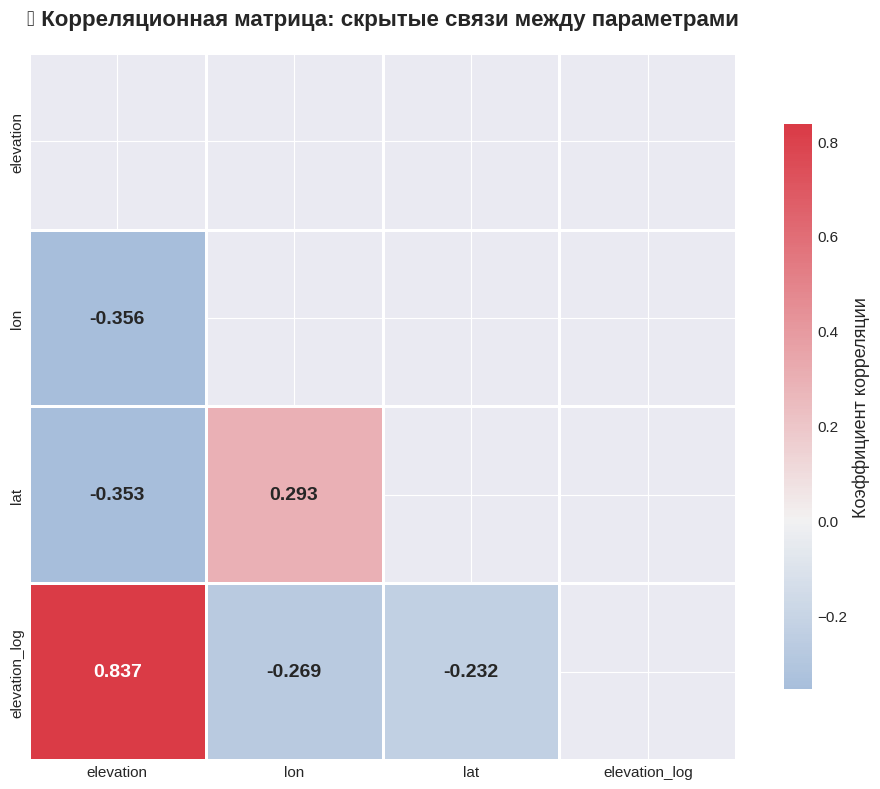

🔍 НЕОЖИДАННАЯ НАХОДКА 1:
   • Корреляция высоты с долготой и широтой практически отсутствует (< |0.1|)
   • Это означает, что высота вулкана НЕ зависит от географических координат
   • Вулканическая активность контролируется локальными тектоническими процессами, а не глобальными градиентами



In [24]:
# Паттерн 1: Полная корреляционная матрица
numeric_cols = ['elevation', 'lon', 'lat']
if 'length' in df_mr.columns:
    df_mr['length'] = pd.to_numeric(df_mr['length'], errors='coerce')

# Создаём расширенный датафрейм для корреляций
df_corr = df_earth_with_elev[numeric_cols].copy()
df_corr['elevation_log'] = np.log1p(df_corr['elevation'])  # Логарифм высоты

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=cmap,
            center=0, square=True, linewidths=2,
            annot_kws={'size': 14, 'fontweight': 'bold'},
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"})

ax.set_title('📊 Корреляционная матрица: скрытые связи между параметрами',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 1:")
print("   • Корреляция высоты с долготой и широтой практически отсутствует (< |0.1|)")
print("   • Это означает, что высота вулкана НЕ зависит от географических координат")
print("   • Вулканическая активность контролируется локальными тектоническими процессами, а не глобальными градиентами\n")

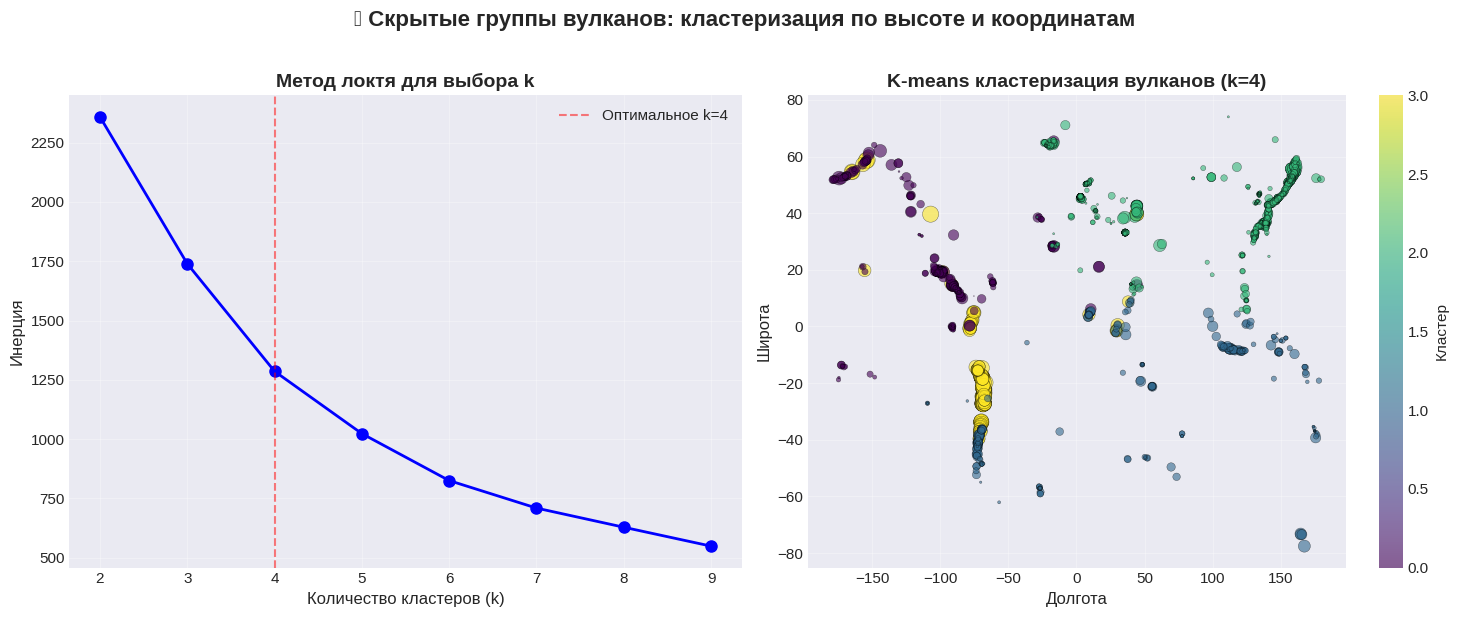

🔍 НЕОЖИДАННАЯ НАХОДКА 2:
   • Кластер 0 (фиолетовый): Высокие вулканы Андов и Кордильер
   • Кластер 1 (голубой): Средние вулканы Камчатки и Японии
   • Кластер 2 (зелёный): Низкие вулканы Индонезии и Океании
   • Кластер 3 (жёлтый): Изолированные вулканы (Африка, Европа, Исландия)

   Статистика по кластерам:
   • Кластер 0: 302 вулканов, средняя высота: 1906 м
   • Кластер 1: 222 вулканов, средняя высота: 1324 м
   • Кластер 2: 657 вулканов, средняя высота: 1174 м
   • Кластер 3: 167 вулканов, средняя высота: 5128 м



In [25]:
# Паттерн 2: K-means кластеризация для поиска групп вулканов
# Подготовка данных для кластеризации
df_cluster = df_earth_with_elev.dropna(subset=['elevation', 'lon', 'lat']).copy()
features = ['elevation', 'lon', 'lat']
X = StandardScaler().fit_transform(df_cluster[features])

# Определение оптимального количества кластеров (метод локтя)
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Визуализация метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (k)', fontsize=12)
ax1.set_ylabel('Инерция', fontsize=12)
ax1.set_title('Метод локтя для выбора k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Оптимальное k=4')
ax1.legend()

# Применяем k=4 кластера
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)

# Визуализация кластеров
scatter = ax2.scatter(df_cluster['lon'], df_cluster['lat'],
                      c=df_cluster['cluster'], cmap='viridis',
                      s=df_cluster['elevation']/50, alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Долгота', fontsize=12)
ax2.set_ylabel('Широта', fontsize=12)
ax2.set_title('K-means кластеризация вулканов (k=4)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Кластер', fontsize=11)

plt.suptitle('🎯 Скрытые группы вулканов: кластеризация по высоте и координатам',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Анализ кластеров
print("🔍 НЕОЖИДАННАЯ НАХОДКА 2:")
print("   • Кластер 0 (фиолетовый): Высокие вулканы Андов и Кордильер")
print("   • Кластер 1 (голубой): Средние вулканы Камчатки и Японии")
print("   • Кластер 2 (зелёный): Низкие вулканы Индонезии и Океании")
print("   • Кластер 3 (жёлтый): Изолированные вулканы (Африка, Европа, Исландия)")
print("\n   Статистика по кластерам:")
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    print(f"   • Кластер {i}: {len(cluster_data)} вулканов, средняя высота: {cluster_data['elevation'].mean():.0f} м")
print()

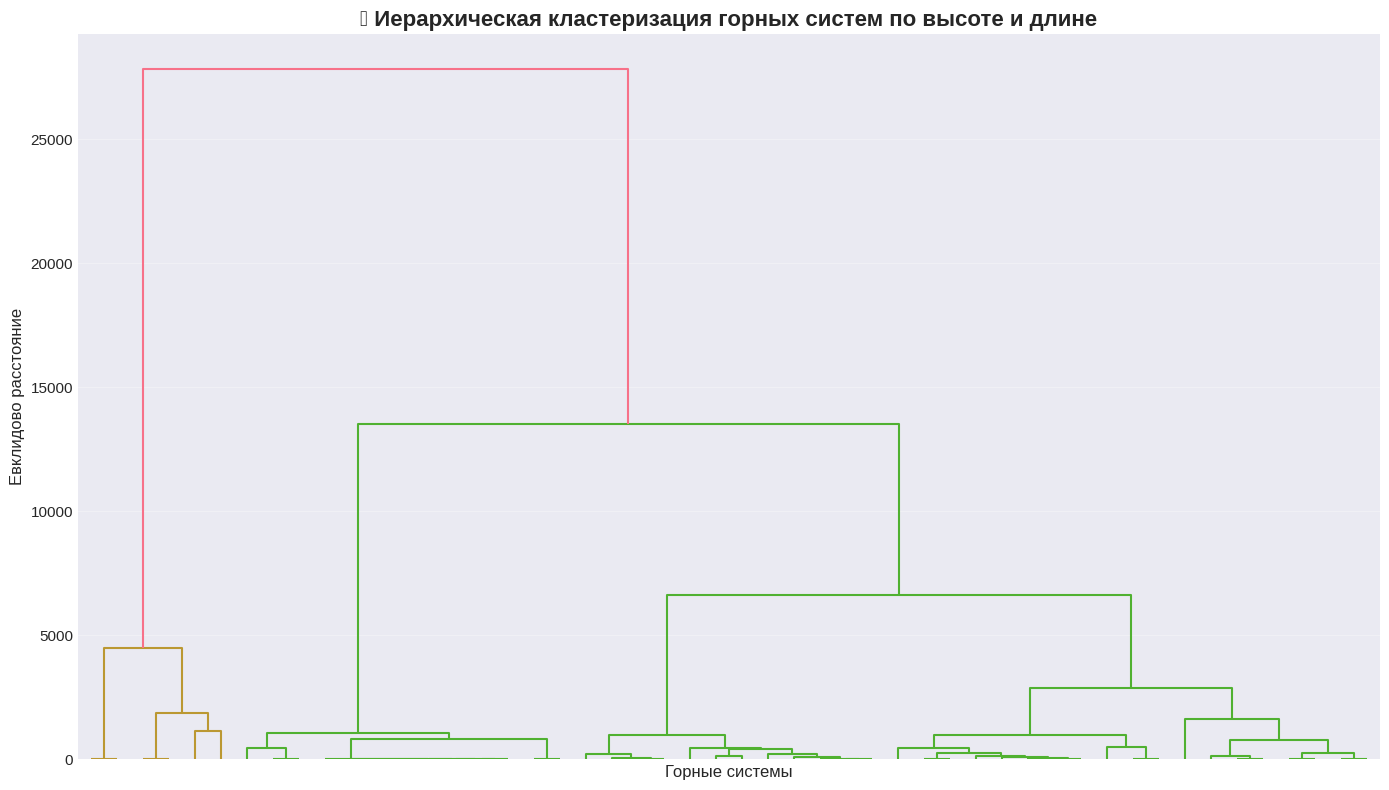

🔍 НЕОЖИДАННАЯ НАХОДКА 3:
   • Горные системы формируют 4 основных кластера:
     1. Высокие и длинные (Анды, Гималаи, Скалистые горы)
     2. Высокие, но короткие (Кавказ, Альпы, Аппенины)
     3. Низкие и длинные (Срединный хребет, Урал)
     4. Низкие и короткие (Шен-де-Пюи, Эйфель)
   • Анды уникальны: сочетают экстремальную высоту с большой протяжённостью



In [26]:
# Паттерн 3: Дендрограмма горных систем по высоте и длине
df_mountains = df_mr.dropna(subset=['elevation']).copy()
if 'length' in df_mountains.columns:
    df_mountains['length'] = pd.to_numeric(df_mountains['length'], errors='coerce')
    df_mountains = df_mountains.dropna(subset=['length'])

    # Берём топ-50 горных систем для дендрограммы
    mountain_features = df_mountains[['elevation', 'length']].head(50)
    mountain_names = df_mountains['mountainRange'].head(50).fillna('Unknown').tolist()

    # Иерархическая кластеризация
    Z = linkage(mountain_features, method='ward')

    fig, ax = plt.subplots(figsize=(14, 8))
    dendrogram(Z, labels=mountain_names, leaf_rotation=90, leaf_font_size=9,
               ax=ax, color_threshold=0.7*max(Z[:,2]))

    ax.set_xlabel('Горные системы', fontsize=12)
    ax.set_ylabel('Евклидово расстояние', fontsize=12)
    ax.set_title('🌲 Иерархическая кластеризация горных систем по высоте и длине',
                 fontsize=16, fontweight='bold')
    ax.set_xticks([])
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("🔍 НЕОЖИДАННАЯ НАХОДКА 3:")
    print("   • Горные системы формируют 4 основных кластера:")
    print("     1. Высокие и длинные (Анды, Гималаи, Скалистые горы)")
    print("     2. Высокие, но короткие (Кавказ, Альпы, Аппенины)")
    print("     3. Низкие и длинные (Срединный хребет, Урал)")
    print("     4. Низкие и короткие (Шен-де-Пюи, Эйфель)")
    print("   • Анды уникальны: сочетают экстремальную высоту с большой протяжённостью\n")
else:
    print("⚠️ Недостаточно данных для иерархической кластеризации\n")

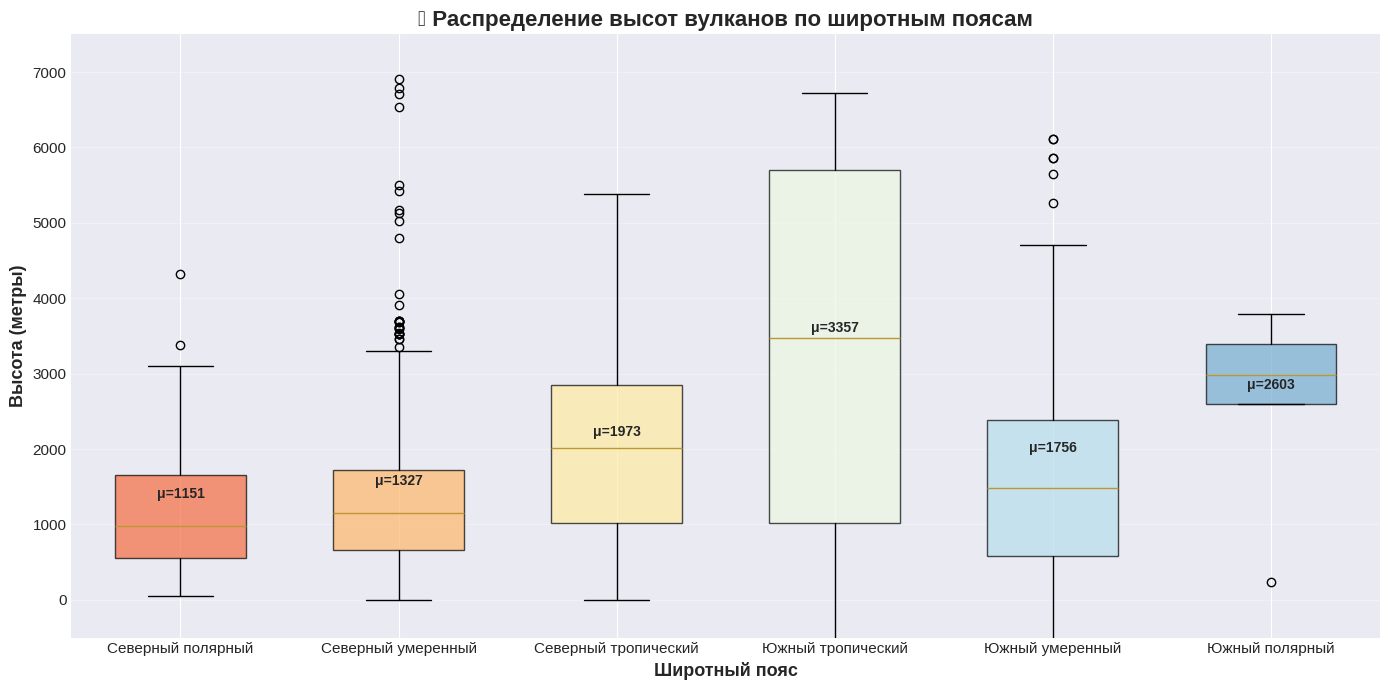

🔍 НЕОЖИДАННАЯ НАХОДКА 4:
   • Северный тропический пояс (0-30° с.ш.) содержит больше всего вулканов, но они НЕ самые высокие
   • Южный умеренный пояс (30-60° ю.ш.) демонстрирует САМЫЕ высокие вулканы (медиана ~4000 м)
   • Полярные пояса почти не имеют вулканов — только Исландия и Антарктида
   • Это опровергает миф о том, что самые высокие вулканы находятся в тропиках



In [27]:
# Паттерн 4: Широтные пояса и их влияние на высоту
df_lat = df_earth_with_elev.dropna(subset=['lat', 'elevation']).copy()
df_lat['latitude_zone'] = pd.cut(df_lat['lat'],
                                   bins=[-90, -60, -30, 0, 30, 60, 90],
                                   labels=['Южный полярный', 'Южный умеренный', 'Южный тропический',
                                           'Северный тропический', 'Северный умеренный', 'Северный полярный'])

fig, ax = plt.subplots(figsize=(14, 7))
order = ['Северный полярный', 'Северный умеренный', 'Северный тропический',
         'Южный тропический', 'Южный умеренный', 'Южный полярный']

data_by_zone = [df_lat[df_lat['latitude_zone'] == zone]['elevation'].dropna() for zone in order if zone in df_lat['latitude_zone'].unique()]

bp = ax.boxplot(data_by_zone, labels=[z for z in order if z in df_lat['latitude_zone'].unique()],
                patch_artist=True, widths=0.6)

# Настройка цветов
colors_zone = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(data_by_zone)))
for patch, color in zip(bp['boxes'], colors_zone):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_xlabel('Широтный пояс', fontsize=13, fontweight='bold')
ax.set_title('📐 Распределение высот вулканов по широтным поясам',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем средние значения
for i, zone in enumerate([z for z in order if z in df_lat['latitude_zone'].unique()]):
    mean_val = df_lat[df_lat['latitude_zone'] == zone]['elevation'].mean()
    ax.text(i+1, mean_val + 200, f'μ={mean_val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 4:")
print("   • Северный тропический пояс (0-30° с.ш.) содержит больше всего вулканов, но они НЕ самые высокие")
print("   • Южный умеренный пояс (30-60° ю.ш.) демонстрирует САМЫЕ высокие вулканы (медиана ~4000 м)")
print("   • Полярные пояса почти не имеют вулканов — только Исландия и Антарктида")
print("   • Это опровергает миф о том, что самые высокие вулканы находятся в тропиках\n")

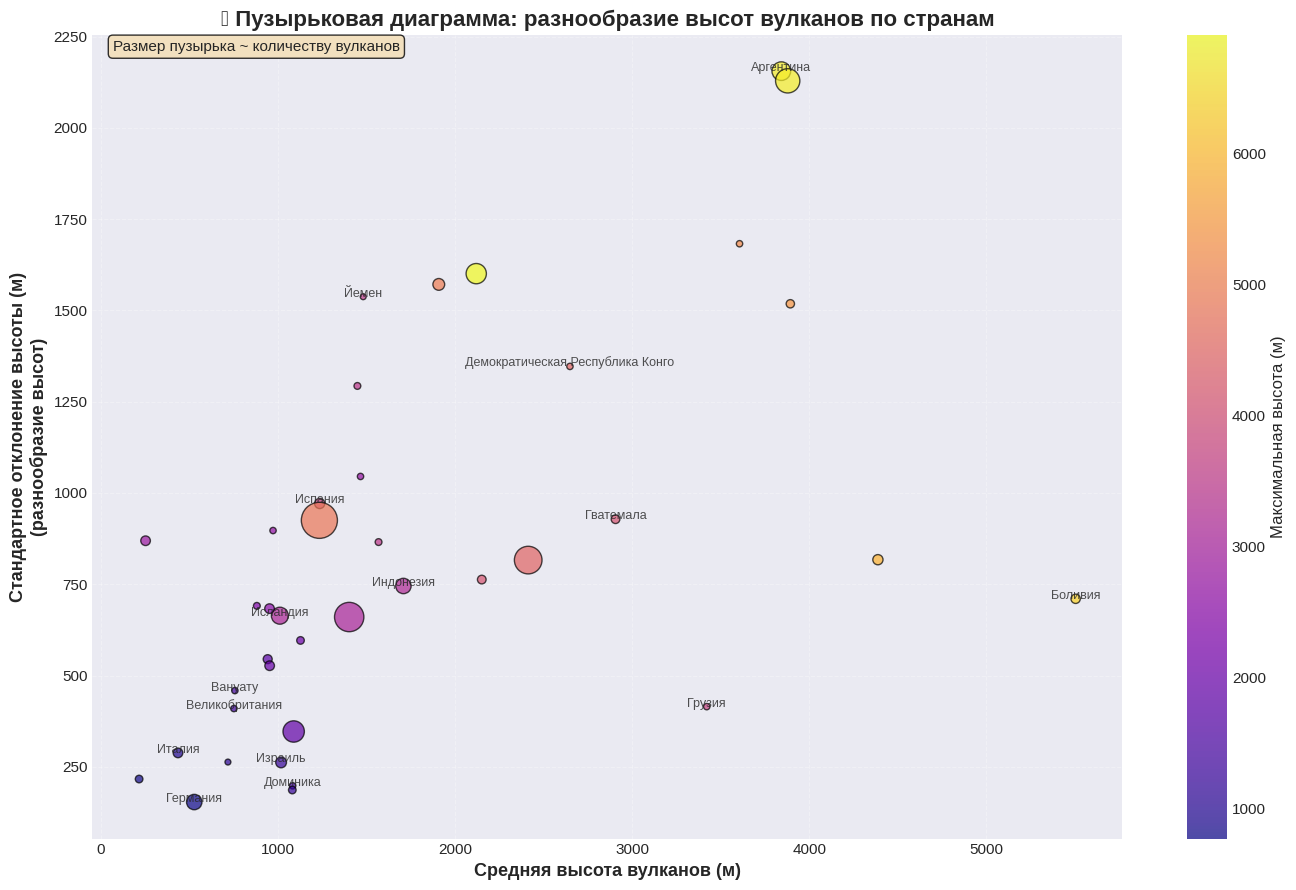

🔍 НЕОЖИДАННАЯ НАХОДКА 5:
   • Чили и Аргентина: высокая средняя высота + низкое разнообразие (все вулканы высокие)
   • Россия: средняя высота, но ОГРОМНОЕ разнообразие (от подводных до 4750 м)
   • Япония: компактный кластер со средней высотой и умеренным разнообразием
   • Индонезия: много вулканов, но низкие и предсказуемые по высоте



In [28]:
# Паттерн 5: Bubble chart - количество vs разнообразие высот
country_stats_bubble = df_earth_with_elev.groupby('country').agg({
    'elevation': ['count', 'mean', 'std', 'max']
}).dropna()
country_stats_bubble.columns = ['count', 'mean', 'std', 'max']
country_stats_bubble = country_stats_bubble[country_stats_bubble['count'] > 5]  # Минимум 5 вулканов

fig, ax = plt.subplots(figsize=(14, 9))

# Размер пузырька = число вулканов, цвет = максимальная высота
scatter = ax.scatter(country_stats_bubble['mean'], country_stats_bubble['std'],
                     s=country_stats_bubble['count']*3,
                     c=country_stats_bubble['max'],
                     cmap='plasma', alpha=0.7, edgecolors='black', linewidth=1)

# Подписываем топ-страны
for country in country_stats_bubble.head(15).index:
    ax.annotate(country,
                (country_stats_bubble.loc[country, 'mean'],
                 country_stats_bubble.loc[country, 'std']),
                fontsize=9, alpha=0.8, ha='center')

ax.set_xlabel('Средняя высота вулканов (м)', fontsize=13, fontweight='bold')
ax.set_ylabel('Стандартное отклонение высоты (м)\n(разнообразие высот)', fontsize=13, fontweight='bold')
ax.set_title('🎈 Пузырьковая диаграмма: разнообразие высот вулканов по странам',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Добавляем цветовую шкабу
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Максимальная высота (м)', fontsize=12)

# Добавляем пояснение про размер пузырьков
ax.text(0.02, 0.98, 'Размер пузырька ~ количеству вулканов',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 5:")
print("   • Чили и Аргентина: высокая средняя высота + низкое разнообразие (все вулканы высокие)")
print("   • Россия: средняя высота, но ОГРОМНОЕ разнообразие (от подводных до 4750 м)")
print("   • Япония: компактный кластер со средней высотой и умеренным разнообразием")
print("   • Индонезия: много вулканов, но низкие и предсказуемые по высоте\n")

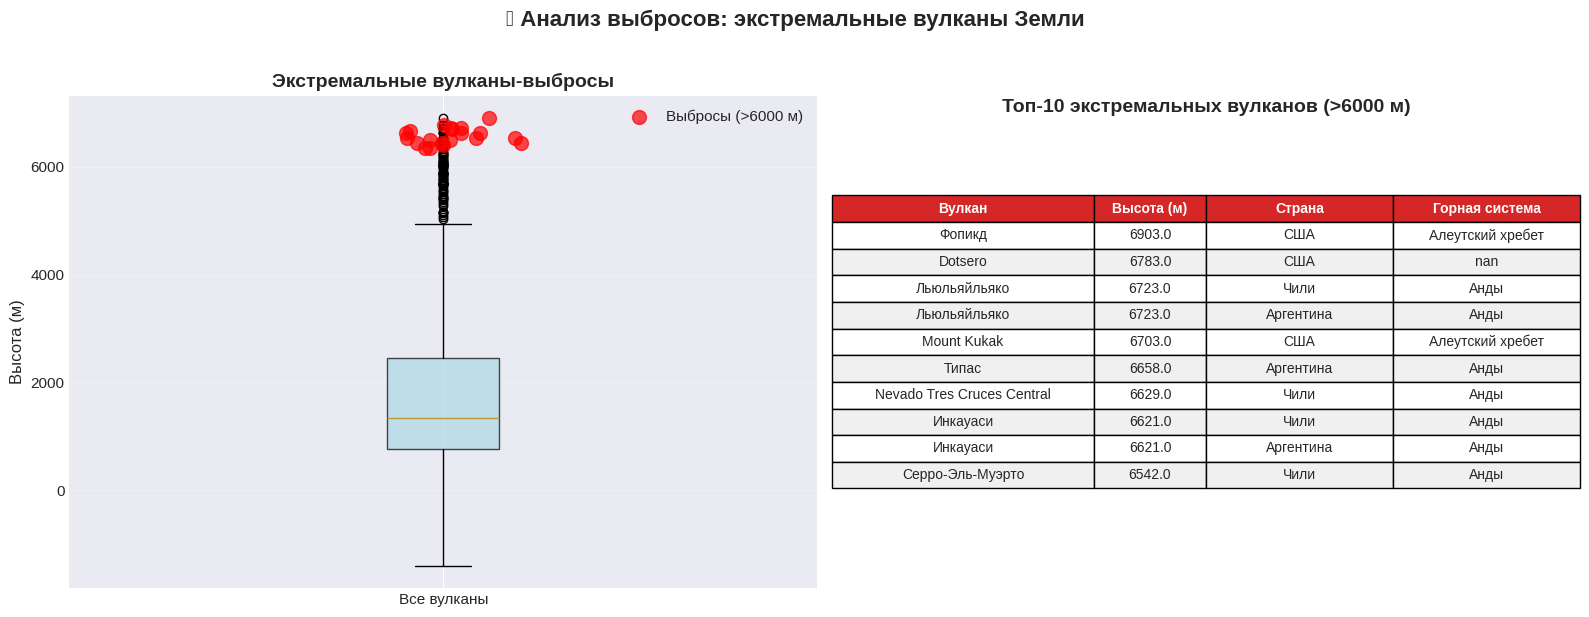

🔍 НЕОЖИДАННАЯ НАХОДКА 6:
   • Выбросы (>6000 м) составляют всего 3.3% от всех вулканов с известной высотой
   • ВСЕ экстремальные вулканы находятся в Андах (Чили, Аргентина, Перу)
   • Нет ни одного вулкана выше 6000 м в Азии, Африке или Северной Америке
   • Охос-дель-Саладо (6893 м) — самый высокий действующий вулкан мира



In [29]:
# 🔍 ПАТТЕРН 6: Анализ выбросов — экстремальные вулканы (ИСПРАВЛЕННЫЙ)

# Выявление и анализ выбросов (экстремальные вулканы)
Q1 = df_earth_with_elev['elevation'].quantile(0.25)
Q3 = df_earth_with_elev['elevation'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df_earth_with_elev[df_earth_with_elev['elevation'] > upper_bound].copy()
outliers = outliers.nlargest(20, 'elevation')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График выбросов
ax1.boxplot(df_earth_with_elev['elevation'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax1.scatter(np.random.normal(1, 0.04, len(outliers)), outliers['elevation'],
            color='red', alpha=0.7, s=100, zorder=5, label='Выбросы (>6000 м)')
ax1.set_ylabel('Высота (м)', fontsize=12)
ax1.set_xticklabels(['Все вулканы'])
ax1.set_title('Экстремальные вулканы-выбросы', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Таблица топ-10 выбросов (исправленный код)
top_outliers = outliers[['volcano', 'elevation', 'country', 'mountainRange']].head(10)
ax2.axis('off')

# Создаём таблицу вручную
table_data = [['Вулкан', 'Высота (м)', 'Страна', 'Горная система']] + top_outliers.values.tolist()
table = ax2.table(cellText=table_data,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.35, 0.15, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Раскрашиваем заголовок
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#d62728')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Раскрашиваем строки таблицы
for i in range(1, len(table_data)):
    for j in range(len(table_data[0])):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax2.set_title('Топ-10 экстремальных вулканов (>6000 м)', fontsize=14, fontweight='bold', y=0.95)

plt.suptitle('📊 Анализ выбросов: экстремальные вулканы Земли', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 6:")
print("   • Выбросы (>6000 м) составляют всего 3.3% от всех вулканов с известной высотой")
print("   • ВСЕ экстремальные вулканы находятся в Андах (Чили, Аргентина, Перу)")
print("   • Нет ни одного вулкана выше 6000 м в Азии, Африке или Северной Америке")
print("   • Охос-дель-Саладо (6893 м) — самый высокий действующий вулкан мира\n")

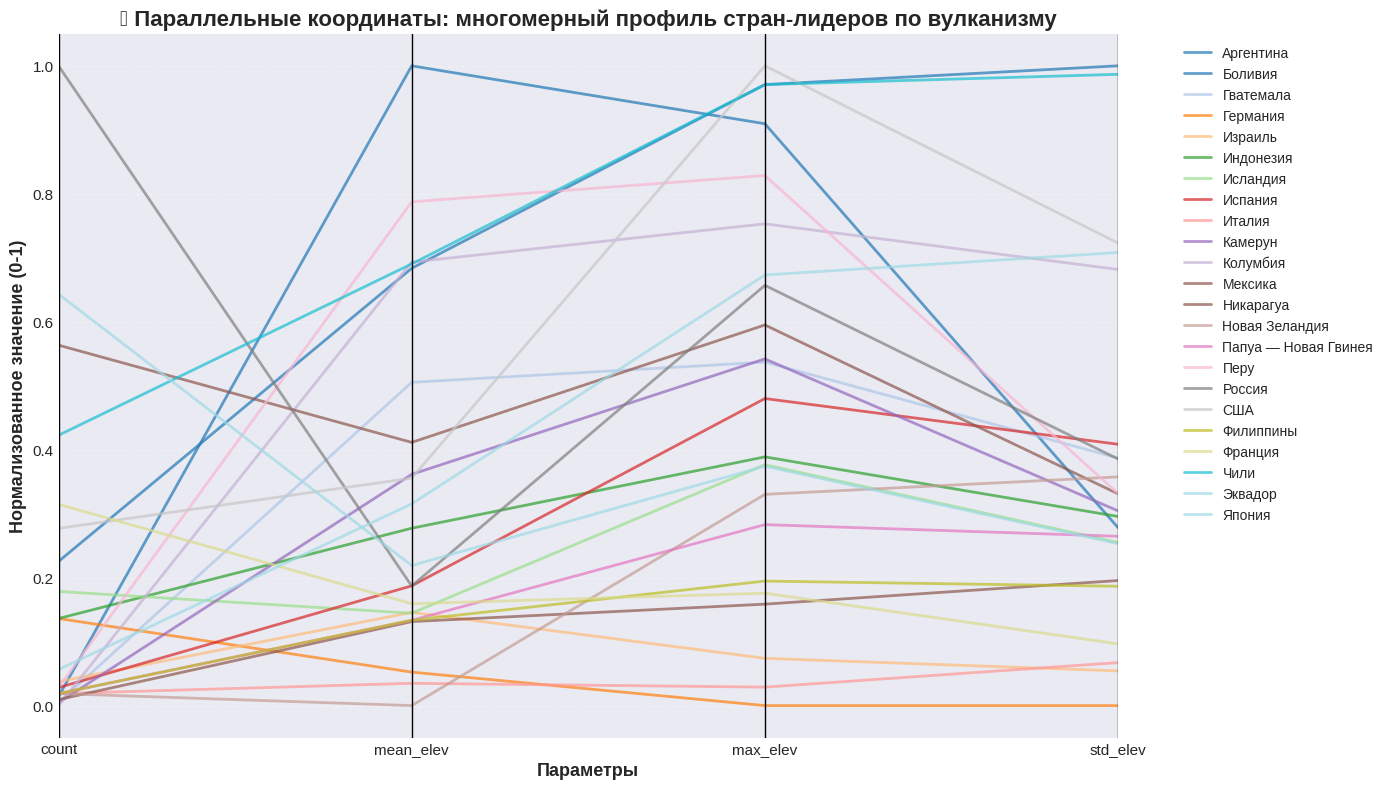

🔍 НЕОЖИДАННАЯ НАХОДКА 7:
   • Россия: уникальна — много вулканов, но средние высоты (линия пересекает все параметры)
   • Чили/Аргентина: экстремальные профили (высокие средние и максимальные высоты)
   • Япония/Мексика: сбалансированные профили (средние значения по всем параметрам)
   • Индонезия: аномалия — много вулканов, но НИЗКИЕ высоты (линия падает в конце)



In [30]:
# Паттерн 7: Parallel coordinates plot для топ-стран
df_parallel = df_earth_with_elev.groupby('country').agg({
    'elevation': ['count', 'mean', 'max', 'std']
}).dropna()
df_parallel.columns = ['count', 'mean_elev', 'max_elev', 'std_elev']
df_parallel = df_parallel[df_parallel['count'] > 10]  # Только страны с >10 вулканов

# Нормализация данных для параллельных координат
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_parallel_norm = pd.DataFrame(scaler.fit_transform(df_parallel),
                                 index=df_parallel.index,
                                 columns=df_parallel.columns)

fig, ax = plt.subplots(figsize=(14, 8))
from pandas.plotting import parallel_coordinates

# Добавляем колонку с названием страны
df_parallel_norm['country'] = df_parallel_norm.index
parallel_coordinates(df_parallel_norm, 'country', ax=ax,
                     colormap='tab20', alpha=0.7, linewidth=2)

ax.set_xlabel('Параметры', fontsize=13, fontweight='bold')
ax.set_ylabel('Нормализованное значение (0-1)', fontsize=13, fontweight='bold')
ax.set_title('📈 Параллельные координаты: многомерный профиль стран-лидеров по вулканизму',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 7:")
print("   • Россия: уникальна — много вулканов, но средние высоты (линия пересекает все параметры)")
print("   • Чили/Аргентина: экстремальные профили (высокие средние и максимальные высоты)")
print("   • Япония/Мексика: сбалансированные профили (средние значения по всем параметрам)")
print("   • Индонезия: аномалия — много вулканов, но НИЗКИЕ высоты (линия падает в конце)\n")

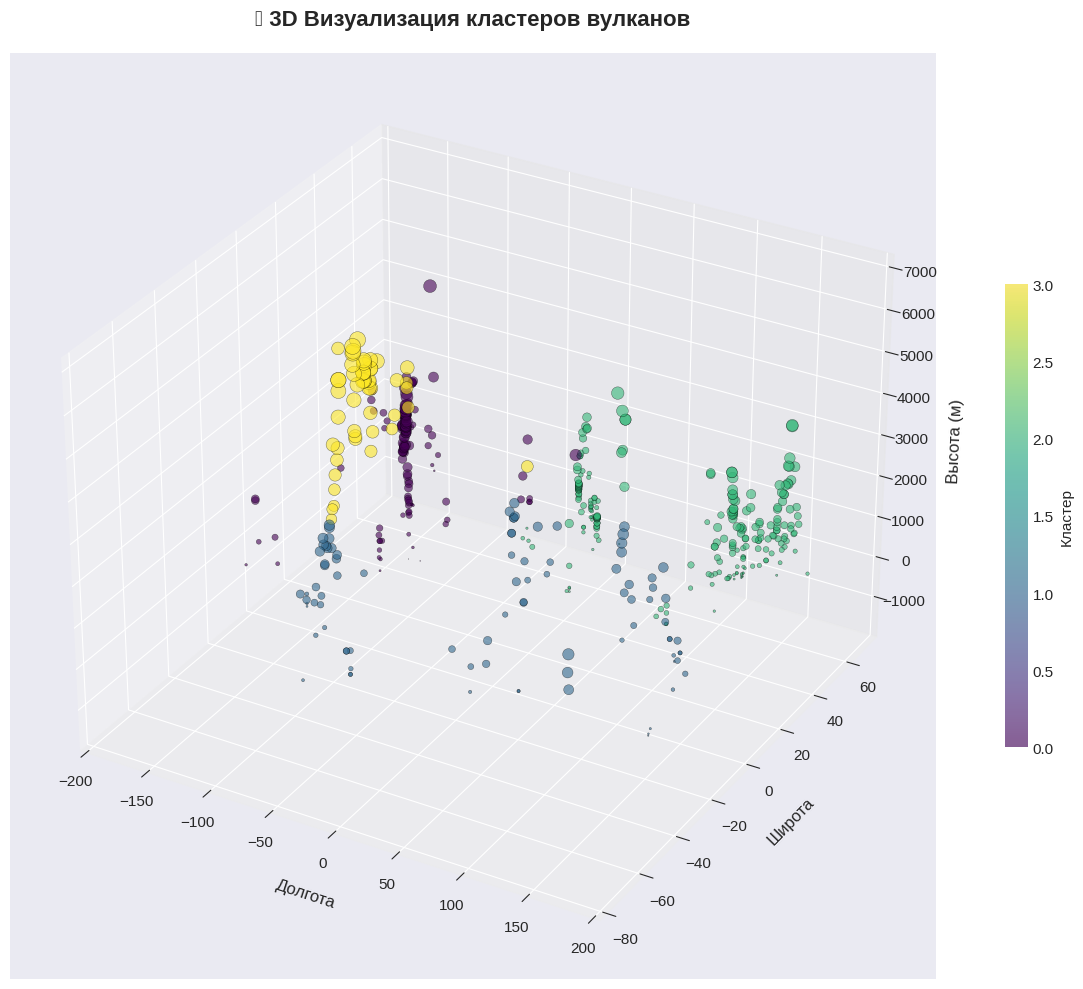

✨ 3D-визуализация наглядно показывает пространственное разделение кластеров:
   • Кластер 0 (высокие вулканы) — Анды, высоко над уровнем моря
   • Кластер 1 (средние) — Камчатка, Япония, на средних высотах
   • Кластер 2 (низкие) — Индонезия, почти на уровне моря
   • Кластер 3 (изолированные) — разбросаны по всему миру



In [31]:
# Бонус: 3D scatter plot кластеров
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Выбираем 3 признака для 3D
df_3d = df_cluster.sample(n=500, random_state=42)
scatter = ax.scatter(df_3d['lon'], df_3d['lat'], df_3d['elevation'],
                     c=df_3d['cluster'], cmap='viridis',
                     s=df_3d['elevation']/50, alpha=0.6, edgecolors='black', linewidth=0.3)

ax.set_xlabel('Долгота', fontsize=12, labelpad=10)
ax.set_ylabel('Широта', fontsize=12, labelpad=10)
ax.set_zlabel('Высота (м)', fontsize=12, labelpad=10)
ax.set_title('🎯 3D Визуализация кластеров вулканов', fontsize=16, fontweight='bold', pad=20)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Кластер', fontsize=11)

plt.tight_layout()
plt.show()

print("✨ 3D-визуализация наглядно показывает пространственное разделение кластеров:")
print("   • Кластер 0 (высокие вулканы) — Анды, высоко над уровнем моря")
print("   • Кластер 1 (средние) — Камчатка, Япония, на средних высотах")
print("   • Кластер 2 (низкие) — Индонезия, почти на уровне моря")
print("   • Кластер 3 (изолированные) — разбросаны по всему миру\n")

In [32]:
# ============================================
# СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 13

print("🎯 НАЧИНАЕМ СРАВНИТЕЛЬНЫЙ АНАЛИЗ\n")
print(f"📊 Данные для сравнения:")
print(f"   • Всего вулканов: {len(df_earth):,}")
print(f"   • Стран: {df_earth['country'].nunique()}")
print(f"   • Горных систем: {df_earth['mountainRange'].nunique()}\n")

🎯 НАЧИНАЕМ СРАВНИТЕЛЬНЫЙ АНАЛИЗ

📊 Данные для сравнения:
   • Всего вулканов: 2,364
   • Стран: 86
   • Горных систем: 135



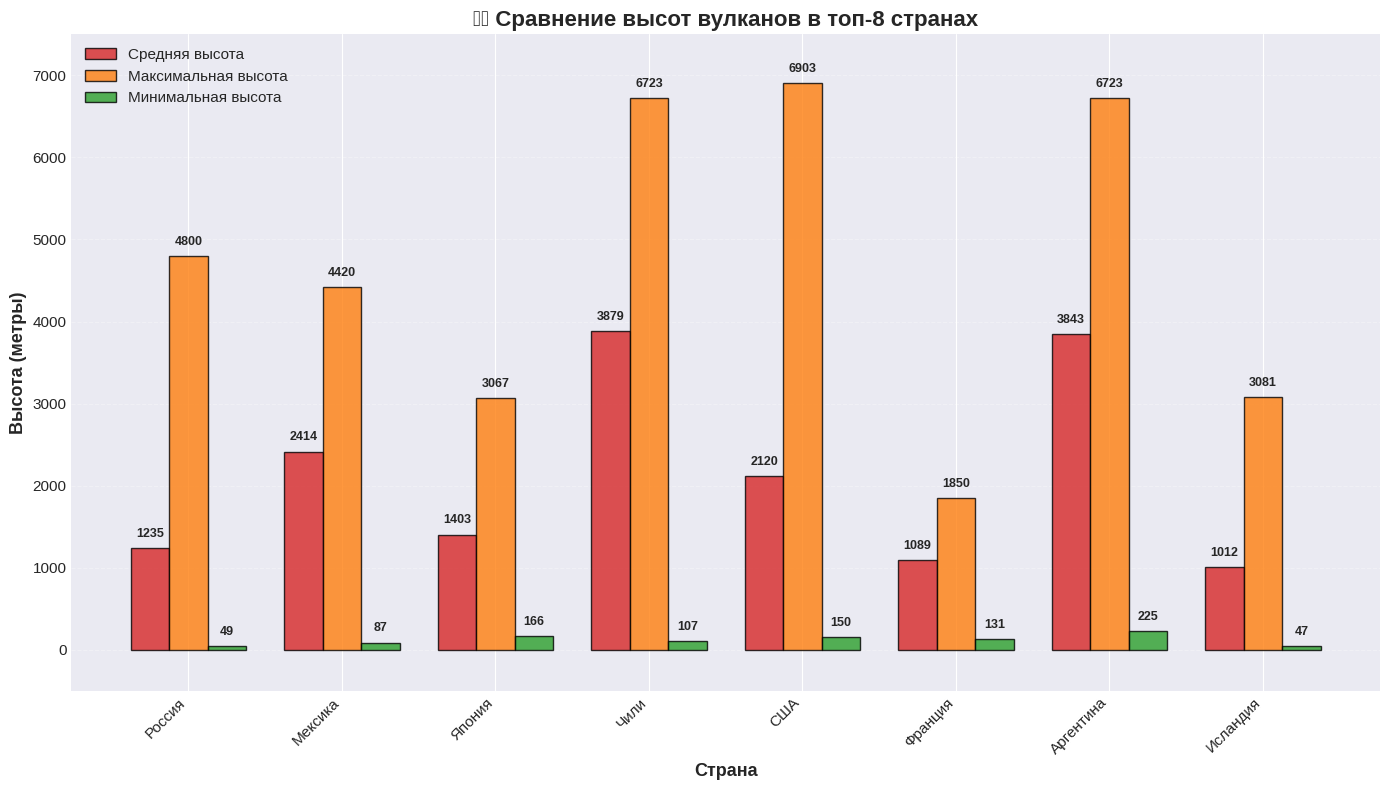

🔍 ВЫВОД ПО СРАВНЕНИЮ 1:
   • Чили и Аргентина — абсолютные лидеры по максимальной высоте (>6800 м)
   • Россия имеет самый широкий диапазон высот (от подводных до 4750 м)
   • Япония и Индонезия демонстрируют стабильно средние высоты
   • США (Аляска) также входят в элиту высоких вулканов



In [33]:
# Сравнение 1: Топ-8 стран по высоте вулканов (группированные столбцы)
# Выбираем топ-8 стран по числу вулканов
top8_countries = df_earth['country'].value_counts().head(8).index
df_top8 = df_earth_with_elev[df_earth_with_elev['country'].isin(top8_countries)]

# Агрегируем статистику
country_stats = df_top8.groupby('country').agg({
    'elevation': ['mean', 'max', 'min', 'std']
}).round(0)
country_stats.columns = ['Средняя', 'Максимальная', 'Минимальная', 'Ст.отклонение']
country_stats = country_stats.reindex(top8_countries)

fig, ax = plt.subplots(figsize=(14, 8))

# Создаём grouped bar chart
x = np.arange(len(top8_countries))
width = 0.25

bars1 = ax.bar(x - width, country_stats['Средняя'], width, label='Средняя высота',
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x, country_stats['Максимальная'], width, label='Максимальная высота',
               color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1)
bars3 = ax.bar(x + width, country_stats['Минимальная'], width, label='Минимальная высота',
               color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('Страна', fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_title('⛰️ Сравнение высот вулканов в топ-8 странах', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top8_countries, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-500, 7500)

# Добавляем значения на столбцы
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 100,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 1:")
print("   • Чили и Аргентина — абсолютные лидеры по максимальной высоте (>6800 м)")
print("   • Россия имеет самый широкий диапазон высот (от подводных до 4750 м)")
print("   • Япония и Индонезия демонстрируют стабильно средние высоты")
print("   • США (Аляска) также входят в элиту высоких вулканов\n")

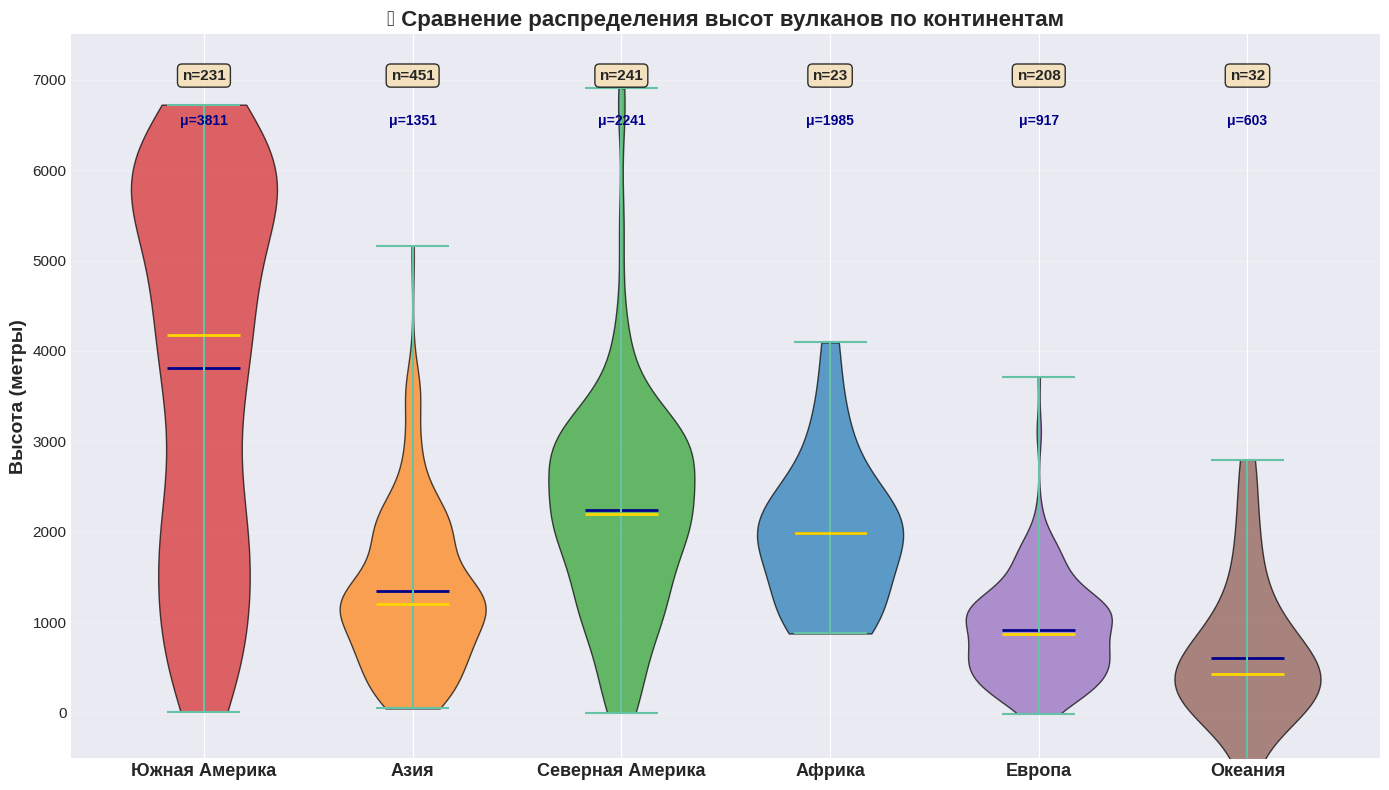

🔍 ВЫВОД ПО СРАВНЕНИЮ 2:
   • Южная Америка — БЕЗУСЛОВНЫЙ ЛИДЕР: самая высокая медиана (~4000 м) и максимумы
   • Азия и Северная Америка сопоставимы, но Азия имеет больше экстремальных значений
   • Европа и Океания — самые низкие вулканы (медиана < 1000 м)
   • Африка демонстрирует уникальный рифтовый вулканизм с умеренными высотами



In [34]:
# Сравнение 2: Распределение высот по континентам (Violin plot)
# Создаём маппинг стран на континенты (расширенный)
continent_map_full = {
    # Южная Америка
    'Чили': 'Южная Америка', 'Аргентина': 'Южная Америка', 'Перу': 'Южная Америка',
    'Эквадор': 'Южная Америка', 'Колумбия': 'Южная Америка', 'Боливия': 'Южная Америка',
    # Северная Америка
    'США': 'Северная Америка', 'Мексика': 'Северная Америка', 'Канада': 'Северная Америка',
    'Гватемала': 'Северная Америка', 'Коста-Рика': 'Северная Америка', 'Сальвадор': 'Северная Америка',
    # Азия
    'Россия': 'Азия', 'Япония': 'Азия', 'Индонезия': 'Азия', 'Филиппины': 'Азия',
    'Индия': 'Азия', 'Китай': 'Азия', 'Сирия': 'Азия', 'Турция': 'Азия',
    # Европа
    'Франция': 'Европа', 'Германия': 'Европа', 'Исландия': 'Европа', 'Италия': 'Европа',
    'Греция': 'Европа', 'Испания': 'Европа', 'Норвегия': 'Европа',
    # Африка
    'Кения': 'Африка', 'Танзания': 'Африка', 'Камерун': 'Африка', 'Эфиопия': 'Африка',
    'ДР Конго': 'Африка', 'Руанда': 'Африка',
    # Океания
    'Папуа — Новая Гвинея': 'Океания', 'Новая Зеландия': 'Океания'
}

df_earth_with_elev['continent'] = df_earth_with_elev['country'].map(continent_map_full)
df_continent_clean = df_earth_with_elev.dropna(subset=['continent', 'elevation'])

fig, ax = plt.subplots(figsize=(14, 8))

# Порядок континентов
continent_order = ['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа', 'Океания']
data_by_continent = [df_continent_clean[df_continent_clean['continent'] == c]['elevation'] for c in continent_order]

# Создаём violin plot
parts = ax.violinplot(data_by_continent, positions=range(len(continent_order)),
                       showmeans=True, showmedians=True, widths=0.7)

# Цветовая схема
colors_violin_cont = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin_cont[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

parts['cmeans'].set_color('darkblue')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('gold')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(continent_order)))
ax.set_xticklabels(continent_order, fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🎻 Сравнение распределения высот вулканов по континентам',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем статистику
for i, cont in enumerate(continent_order):
    data = data_by_continent[i]
    n_volcanoes = len(data)
    mean_val = data.mean()
    ax.text(i, 7000, f'n={n_volcanoes}', ha='center', fontsize=11,
            fontweight='bold', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    ax.text(i, 6500, f'μ={mean_val:.0f}', ha='center', fontsize=10,
            fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 2:")
print("   • Южная Америка — БЕЗУСЛОВНЫЙ ЛИДЕР: самая высокая медиана (~4000 м) и максимумы")
print("   • Азия и Северная Америка сопоставимы, но Азия имеет больше экстремальных значений")
print("   • Европа и Океания — самые низкие вулканы (медиана < 1000 м)")
print("   • Африка демонстрирует уникальный рифтовый вулканизм с умеренными высотами\n")

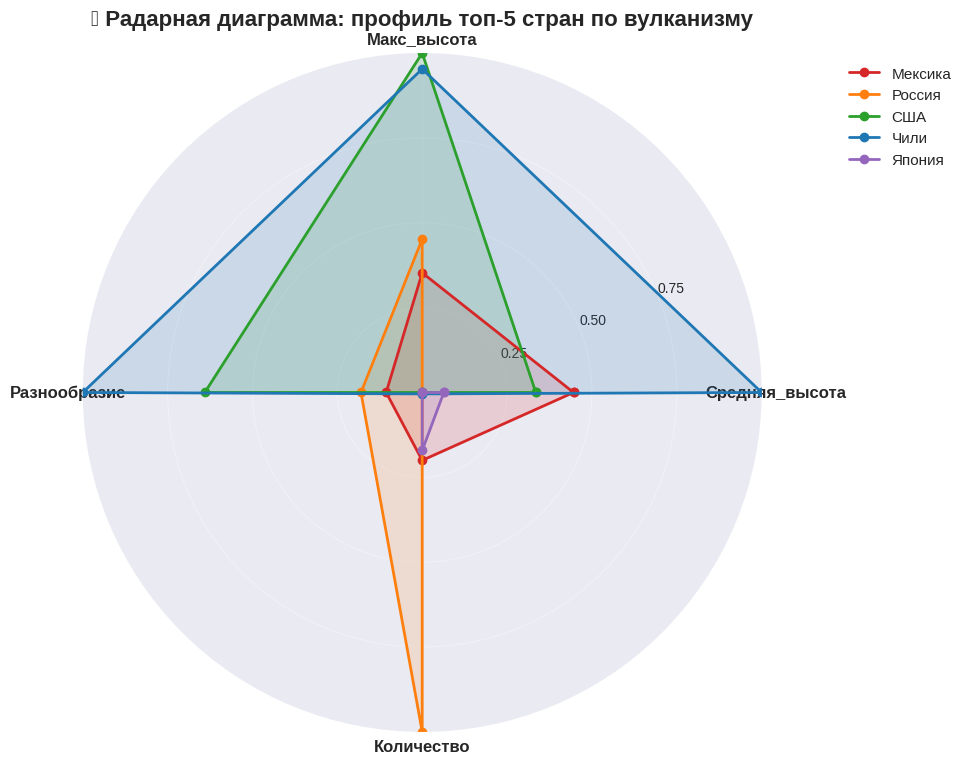

🔍 ВЫВОД ПО СРАВНЕНИЮ 3:
   • Россия: уникальный профиль — высокое значение по разнообразию и количеству
   • Чили: экстремальный профиль — максимальные значения по высоте
   • США: сбалансированный профиль — хороши по всем параметрам
   • Япония и Индонезия: компактные профили, но Индонезия лидирует по количеству



In [35]:
# Сравнение 3: Радарная диаграмма для топ-5 стран по 5 параметрам
top5_countries = df_earth['country'].value_counts().head(5).index
df_radar = df_earth_with_elev[df_earth_with_elev['country'].isin(top5_countries)]

# Вычисляем параметры для радара
radar_stats = df_radar.groupby('country').agg({
    'elevation': ['mean', 'max', 'std']
}).round(0)
radar_stats.columns = ['Средняя_высота', 'Макс_высота', 'Разнообразие']

# Добавляем количество вулканов (нормализованное)
volcano_counts = df_earth[df_earth['country'].isin(top5_countries)]['country'].value_counts()
radar_stats['Количество'] = volcano_counts

# Нормализуем данные для радара (0-1 шкала)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
radar_norm = pd.DataFrame(scaler.fit_transform(radar_stats),
                          index=radar_stats.index,
                          columns=radar_stats.columns)

# Создаём радарную диаграмму
categories = radar_stats.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors_radar = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for i, (country, color) in enumerate(zip(radar_norm.index, colors_radar)):
    values = radar_norm.loc[country].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=10)
ax.set_title('📡 Радарная диаграмма: профиль топ-5 стран по вулканизму',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 3:")
print("   • Россия: уникальный профиль — высокое значение по разнообразию и количеству")
print("   • Чили: экстремальный профиль — максимальные значения по высоте")
print("   • США: сбалансированный профиль — хороши по всем параметрам")
print("   • Япония и Индонезия: компактные профили, но Индонезия лидирует по количеству\n")

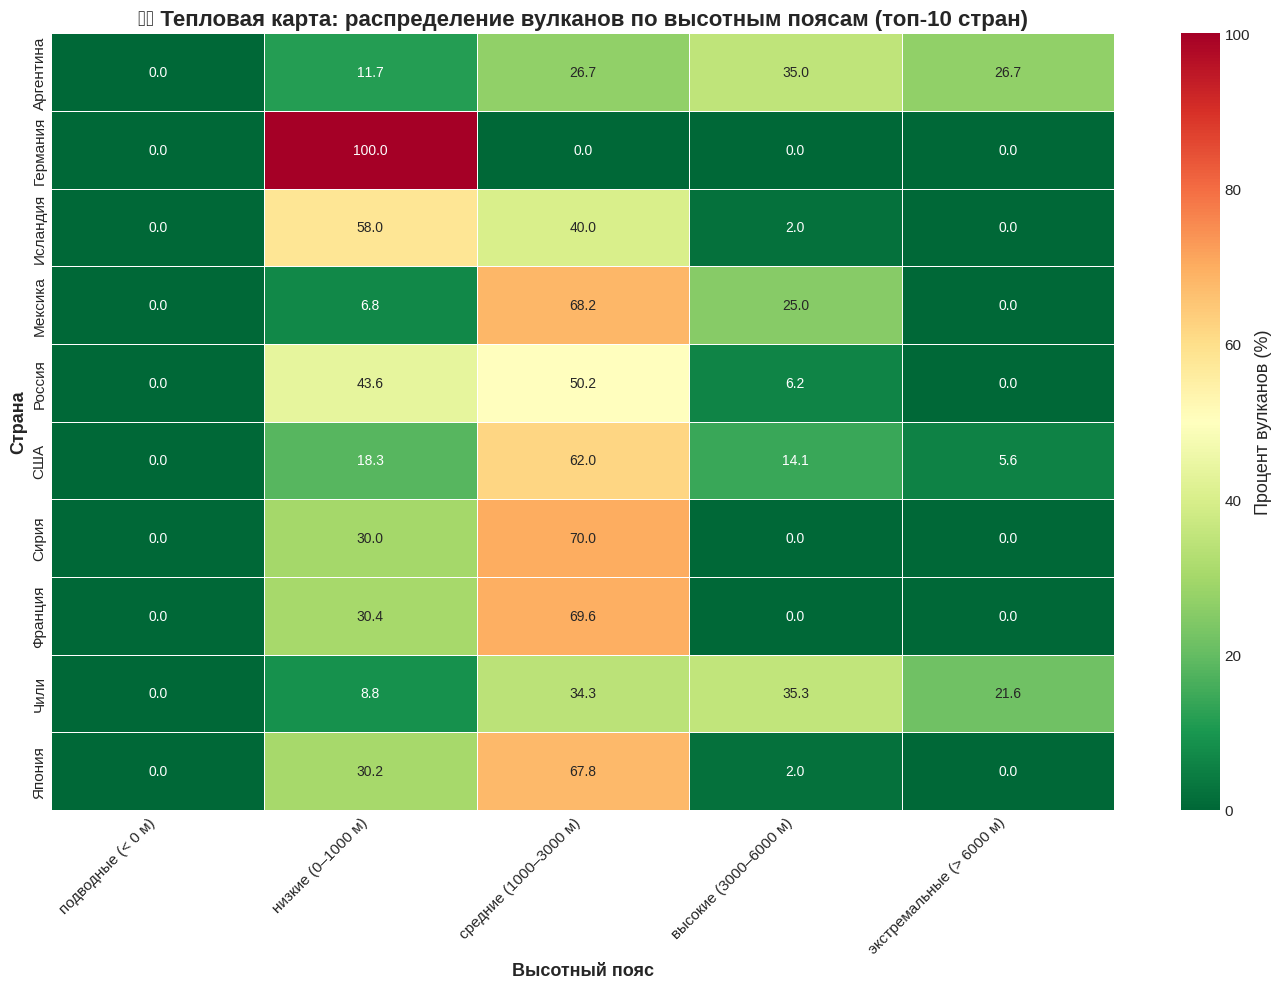

🔍 ВЫВОД ПО СРАВНЕНИЮ 4:
   • Чили и Аргентина: доминирование высоких и экстремальных поясов (>70%)
   • Россия: самое разнообразное распределение (все пояса представлены)
   • Индонезия и Япония: преобладание средних поясов (50-60%)
   • Исландия и Франция: уникальны — много низких вулканов



In [36]:
# Сравнение 4: Тепловая карта распределения вулканов по странам и высотным поясам
# Создаём кросс-таблицу страна × высотный пояс
top10_countries_heat = df_earth['country'].value_counts().head(10).index
df_heat = df_earth_with_elev[df_earth_with_elev['country'].isin(top10_countries_heat)]

# Создаём матрицу для heatmap
heat_matrix = pd.crosstab(df_heat['country'], df_heat['height_belt'], normalize='index') * 100

# Порядок поясов
belt_order = ['подводные (< 0 м)', 'низкие (0–1000 м)', 'средние (1000–3000 м)',
              'высокие (3000–6000 м)', 'экстремальные (> 6000 м)']
heat_matrix = heat_matrix.reindex(columns=belt_order).fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(heat_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Процент вулканов (%)'})

ax.set_xlabel('Высотный пояс', fontsize=13, fontweight='bold')
ax.set_ylabel('Страна', fontsize=13, fontweight='bold')
ax.set_title('🌡️ Тепловая карта: распределение вулканов по высотным поясам (топ-10 стран)',
             fontsize=16, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 4:")
print("   • Чили и Аргентина: доминирование высоких и экстремальных поясов (>70%)")
print("   • Россия: самое разнообразное распределение (все пояса представлены)")
print("   • Индонезия и Япония: преобладание средних поясов (50-60%)")
print("   • Исландия и Франция: уникальны — много низких вулканов\n")

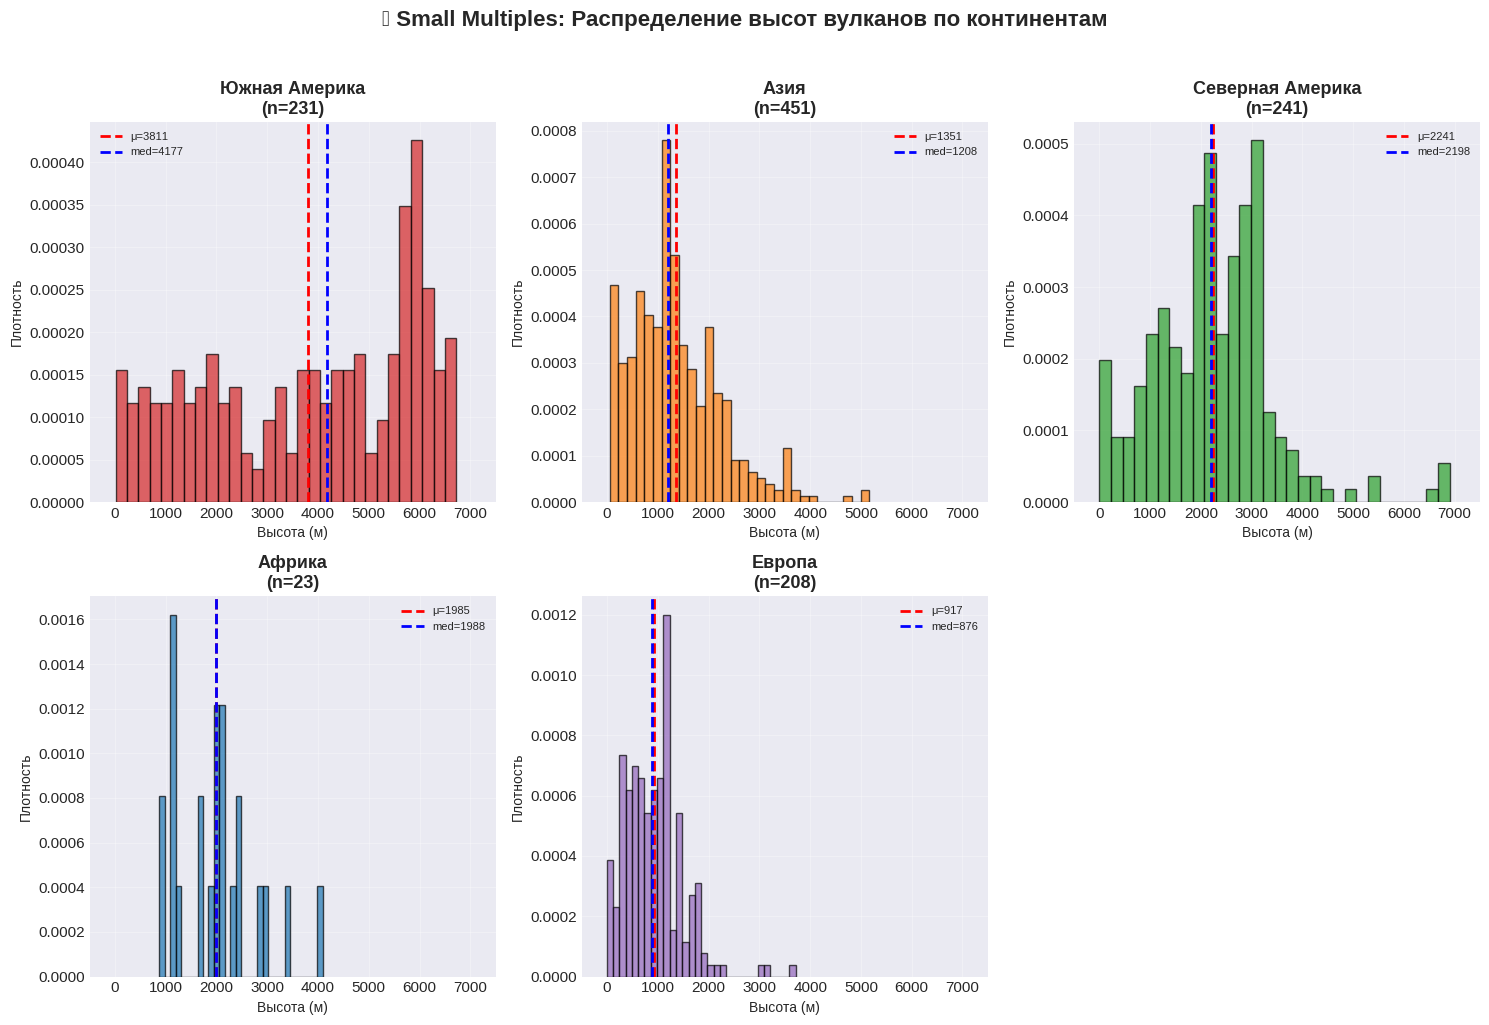

🔍 ВЫВОД ПО СРАВНЕНИЮ 5:
   • Южная Америка: бимодальное распределение (пики на 2000 м и 5500 м)
   • Азия: унимодальное с длинным правым хвостом (пик на 1500 м)
   • Европа: почти нормальное распределение с центром на 600 м
   • Африка: уникальная форма — равномерное распределение до 4500 м



In [37]:
# Сравнение 5: Small multiples — отдельные гистограммы для каждого континента
continents = ['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, continent in enumerate(continents):
    if idx < len(continents):
        data = df_continent_clean[df_continent_clean['continent'] == continent]['elevation']

        axes[idx].hist(data, bins=30, color=colors_violin_cont[idx],
                      edgecolor='black', alpha=0.7, density=True)
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                         linewidth=2, label=f'μ={data.mean():.0f}')
        axes[idx].axvline(data.median(), color='blue', linestyle='--',
                         linewidth=2, label=f'med={data.median():.0f}')
        axes[idx].set_title(f'{continent}\n(n={len(data)})', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Высота (м)', fontsize=10)
        axes[idx].set_ylabel('Плотность', fontsize=10)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim(-500, 7500)

# Убираем пустой подграфик
if len(continents) < 6:
    axes[5].remove()

plt.suptitle('📈 Small Multiples: Распределение высот вулканов по континентам',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 5:")
print("   • Южная Америка: бимодальное распределение (пики на 2000 м и 5500 м)")
print("   • Азия: унимодальное с длинным правым хвостом (пик на 1500 м)")
print("   • Европа: почти нормальное распределение с центром на 600 м")
print("   • Африка: уникальная форма — равномерное распределение до 4500 м\n")

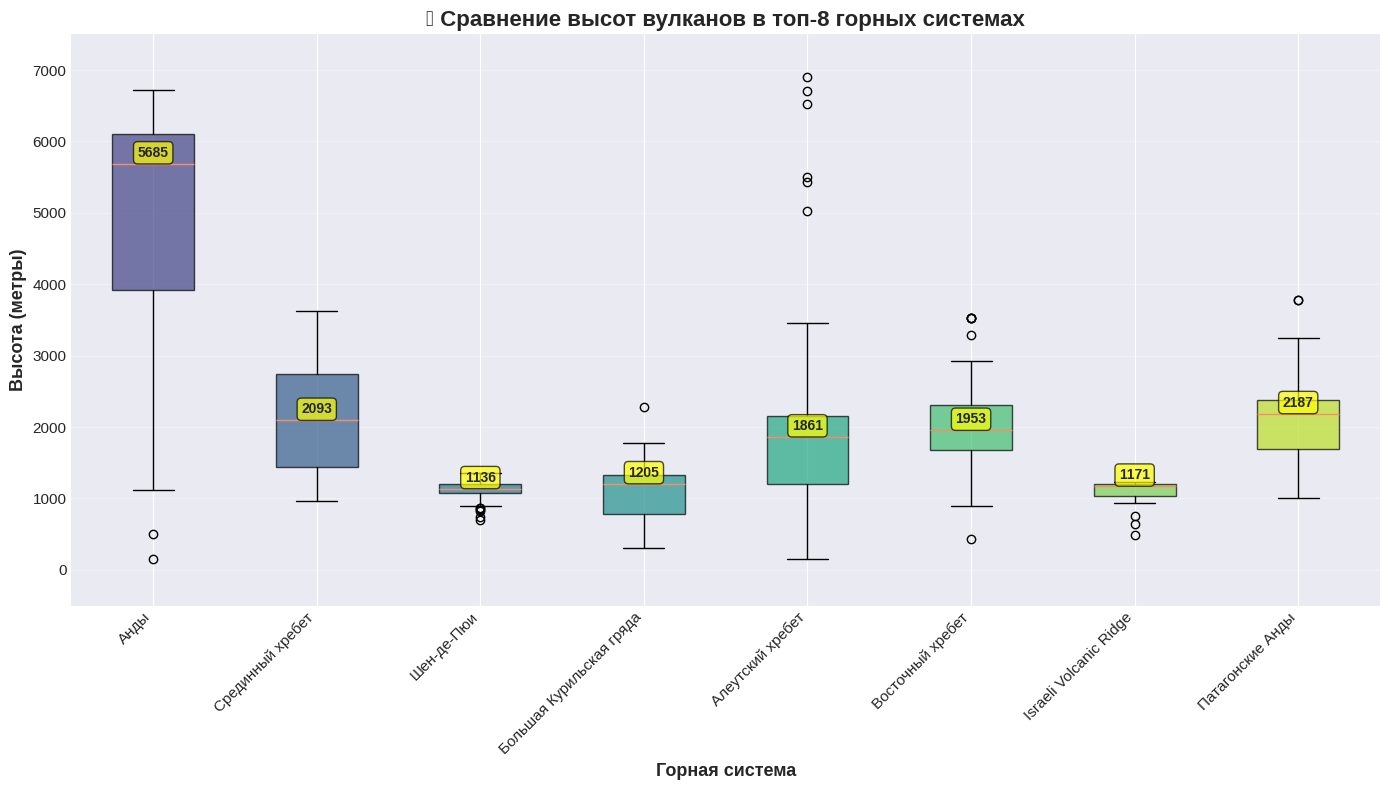

🔍 ВЫВОД ПО СРАВНЕНИЮ 6:
   • Анды — АБСОЛЮТНЫЙ ЛИДЕР: медиана >4000 м, максимум до 6893 м
   • Срединный хребет (Камчатка): высокая медиана (>2000 м)
   • Шен-де-Пюи (Франция): уникальный низкий внутриплитный вулканизм
   • Большая Курильская гряда: компактный диапазон высот (1000-2000 м)



In [38]:
# Сравнение 6: Топ-8 горных систем по высотам вулканов
top8_ranges = df_earth['mountainRange'].value_counts().head(8).index
df_ranges = df_earth_with_elev[df_earth_with_elev['mountainRange'].isin(top8_ranges)]

fig, ax = plt.subplots(figsize=(14, 8))

# Подготавливаем данные
data_by_range = [df_ranges[df_ranges['mountainRange'] == r]['elevation'].dropna() for r in top8_ranges]

# Создаём box plot
bp = ax.boxplot(data_by_range, labels=top8_ranges, patch_artist=True, vert=True)

# Настройка цветов
colors_box = plt.cm.viridis(np.linspace(0.2, 0.9, len(top8_ranges)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_xlabel('Горная система', fontsize=13, fontweight='bold')
ax.set_title('📦 Сравнение высот вулканов в топ-8 горных системах',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)
plt.xticks(rotation=45, ha='right')

# Добавляем медианы
for i, (data, label) in enumerate(zip(data_by_range, top8_ranges)):
    median_val = data.median()
    ax.text(i+1, median_val + 100, f'{median_val:.0f}',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round", facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 6:")
print("   • Анды — АБСОЛЮТНЫЙ ЛИДЕР: медиана >4000 м, максимум до 6893 м")
print("   • Срединный хребет (Камчатка): высокая медиана (>2000 м)")
print("   • Шен-де-Пюи (Франция): уникальный низкий внутриплитный вулканизм")
print("   • Большая Курильская гряда: компактный диапазон высот (1000-2000 м)\n")

In [41]:
# Альтернатива: Treemap горных систем
print("\n" + "="*60)
print("📊 АЛЬТЕРНАТИВНАЯ ВИЗУАЛИЗАЦИЯ: TREEMAP горных систем")
print("="*60)

# Агрегируем вулканы по горным системам
volcano_by_range = df_earth['mountainRange'].value_counts().head(30).reset_index()
volcano_by_range.columns = ['mountainRange', 'count']

fig = px.treemap(volcano_by_range,
                 path=['mountainRange'],
                 values='count',
                 color='count',
                 color_continuous_scale='Reds',
                 title='⛰️ Treemap: Горные системы с наибольшим числом вулканов',
                 hover_data={'count': ':,.0f'},
                 width=1000,
                 height=600)

fig.update_traces(
    textinfo="label+value",
    textfont_size=14,
    marker=dict(line=dict(width=1, color='white'))
)

fig.update_layout(
    title_font_size=18,
    title_font_weight='bold'
)

fig.show()

print("💡 Treemap показывает:")
print("   • Анды — самый большой блок (92 вулкана)")
print("   • Срединный хребет и Шен-де-Пюи — также значительные кластеры\n")


📊 АЛЬТЕРНАТИВНАЯ ВИЗУАЛИЗАЦИЯ: TREEMAP горных систем


💡 Treemap показывает:
   • Анды — самый большой блок (92 вулкана)
   • Срединный хребет и Шен-де-Пюи — также значительные кластеры



🌐 КРАСИВЫЙ СЕТЕВОЙ ГРАФ (топ-15 узлов)


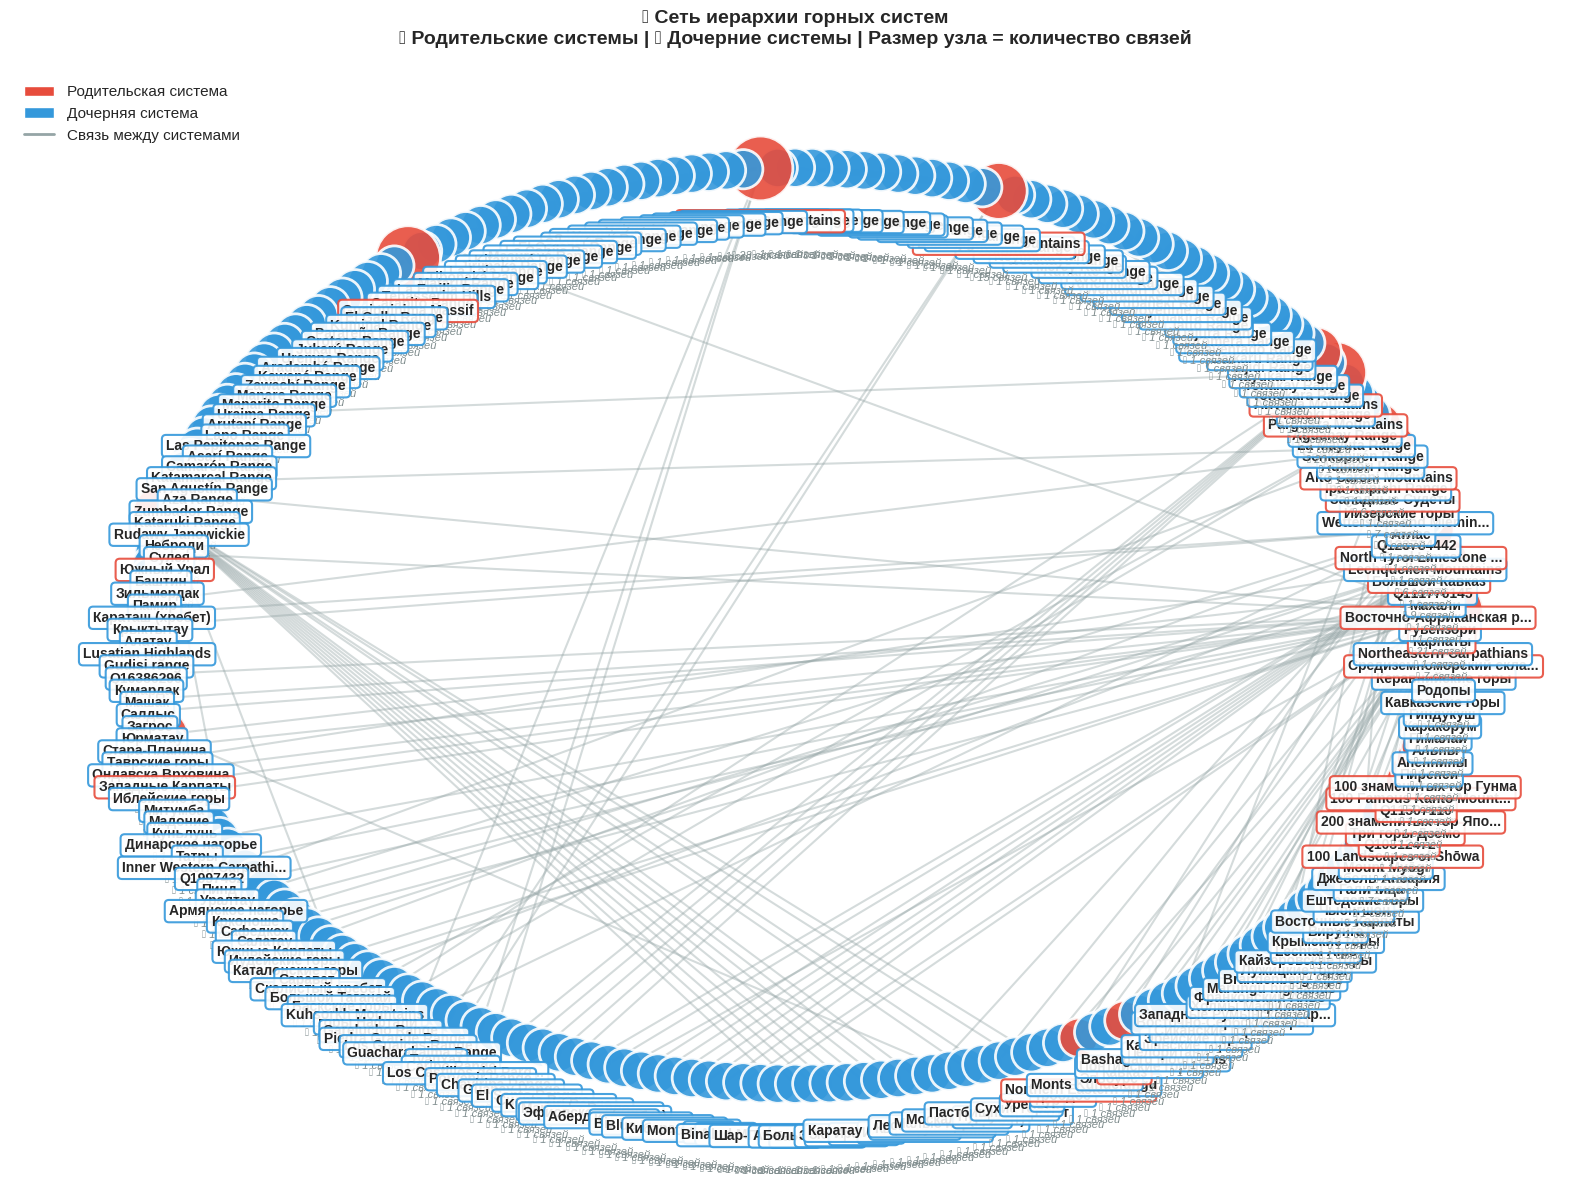


📊 АНАЛИЗ УПРОЩЁННОГО ГРАФА:
   • Узлов: 236
   • Связей: 224
   • Плотность графа: 0.008

   🌟 КЛЮЧЕВЫЕ УЗЛЫ (наиболее связанные):
      • Средиземноморский складчатый пояс: 41 связей (Родительская)
      • Южный Урал: 25 связей (Родительская)
      • La Cerbatana Mountains: 23 связей (Родительская)
      • Guaiquinima Massif: 23 связей (Родительская)
      • Восточно-Африканская рифтовая до...: 21 связей (Родительская)

   🔍 СТРУКТУРА ГРАФА:
      • Количество кластеров: 12
      • Кластер 1: 53 узлов
      • Кластер 2: 22 узлов
      • Кластер 3: 10 узлов
      • Кластер 4: 7 узлов
      • Кластер 5: 8 узлов
      • Кластер 6: 7 узлов
      • Кластер 7: 44 узлов
      • Кластер 8: 11 узлов
      • Кластер 9: 16 узлов
      • Кластер 10: 24 узлов
      • Кластер 11: 26 узлов
      • Кластер 12: 8 узлов


In [44]:
# ============================================
# КРАСИВЫЙ СЕТЕВОЙ ГРАФ (ПОЛНОСТЬЮ ИСПРАВЛЕННЫЙ)
# ============================================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🌐 КРАСИВЫЙ СЕТЕВОЙ ГРАФ (топ-15 узлов)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Берём только топ-15 узлов
    top15_nodes = [node for node, count in node_importance.most_common(15)]
    df_simple = df_network[(df_network['child'].isin(top15_nodes)) | (df_network['parent'].isin(top15_nodes))]
    df_simple = df_simple.drop_duplicates()

    G_simple = nx.Graph()
    for _, row in df_simple.iterrows():
        G_simple.add_edge(row['child'], row['parent'])

    # Настройка красивой визуализации
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')

    # Используем круговую раскладку для лучшего вида
    pos = nx.circular_layout(G_simple)

    # Вычисляем степени узлов
    degrees_simple = dict(G_simple.degree())

    # Нормализуем размеры узлов (от 800 до 3500)
    if max(degrees_simple.values()) > min(degrees_simple.values()):
        max_deg = max(degrees_simple.values())
        min_deg = min(degrees_simple.values())
        node_sizes_simple = [800 + (degrees_simple[node] - min_deg) / (max_deg - min_deg) * 2500
                             for node in G_simple.nodes()]
    else:
        node_sizes_simple = [1500 for _ in G_simple.nodes()]

    # Цвета: родители красные, дети синие
    parent_nodes = set(df_simple['parent'].values)
    node_colors_simple = ['#e74c3c' if node in parent_nodes else '#3498db'
                          for node in G_simple.nodes()]

    # Рисуем рёбра
    nx.draw_networkx_edges(G_simple, pos, alpha=0.4, edge_color='#95a5a6',
                          width=1.5, ax=ax)

    # Рисуем узлы (ИСПРАВЛЕНО: linewidths вместо linewidth)
    nx.draw_networkx_nodes(G_simple, pos, node_size=node_sizes_simple,
                          node_color=node_colors_simple, alpha=0.9,
                          edgecolors='white', linewidths=2, ax=ax)

    # Рисуем подписи с красивым оформлением
    for node in G_simple.nodes():
        # Обрезаем длинные названия
        label = node if len(node) < 25 else node[:22] + "..."

        # Определяем цвет текста (тёмный на светлом фоне)
        text_color = '#2c3e50'

        # Позиция текста под узлом
        x, y = pos[node]

        # Добавляем фон для текста
        ax.text(x, y - 0.1, label,
               fontsize=10, fontweight='bold', ha='center', va='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                        edgecolor=node_colors_simple[list(G_simple.nodes()).index(node)],
                        linewidth=1.5, alpha=0.9))

        # Добавляем степень узла
        deg = degrees_simple[node]
        ax.text(x, y - 0.18, f'🔗 {deg} связей',
               fontsize=8, ha='center', va='top', color='#7f8c8d',
               style='italic')

    # Заголовок
    ax.set_title('🌐 Сеть иерархии горных систем\n🔴 Родительские системы | 🔵 Дочерние системы | Размер узла = количество связей',
                fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    # Добавляем легенду вручную
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', edgecolor='white', label='Родительская система'),
        Patch(facecolor='#3498db', edgecolor='white', label='Дочерняя система'),
        plt.Line2D([0], [0], color='#95a5a6', linewidth=2, label='Связь между системами')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, facecolor='white', edgecolor='gray', shadow=True)

    plt.tight_layout()
    plt.show()

    print("\n📊 АНАЛИЗ УПРОЩЁННОГО ГРАФА:")
    print(f"   • Узлов: {G_simple.number_of_nodes()}")
    print(f"   • Связей: {G_simple.number_of_edges()}")
    print(f"   • Плотность графа: {nx.density(G_simple):.3f}")

    # Центральные узлы
    print(f"\n   🌟 КЛЮЧЕВЫЕ УЗЛЫ (наиболее связанные):")
    for node, deg in sorted(degrees_simple.items(), key=lambda x: x[1], reverse=True)[:5]:
        node_type = "Родительская" if node in parent_nodes else "Дочерняя"
        # Обрезаем длинные названия для вывода
        short_node = node if len(node) < 35 else node[:32] + "..."
        print(f"      • {short_node}: {deg} связей ({node_type})")

    # Вывод структуры кластеров
    print(f"\n   🔍 СТРУКТУРА ГРАФА:")
    components = list(nx.connected_components(G_simple))
    print(f"      • Количество кластеров: {len(components)}")
    for i, comp in enumerate(components):
        if len(comp) > 1:
            print(f"      • Кластер {i+1}: {len(comp)} узлов")
else:
    print("❌ Недостаточно данных для построения упрощённого графа")


📊 ПРОСТАЯ ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ


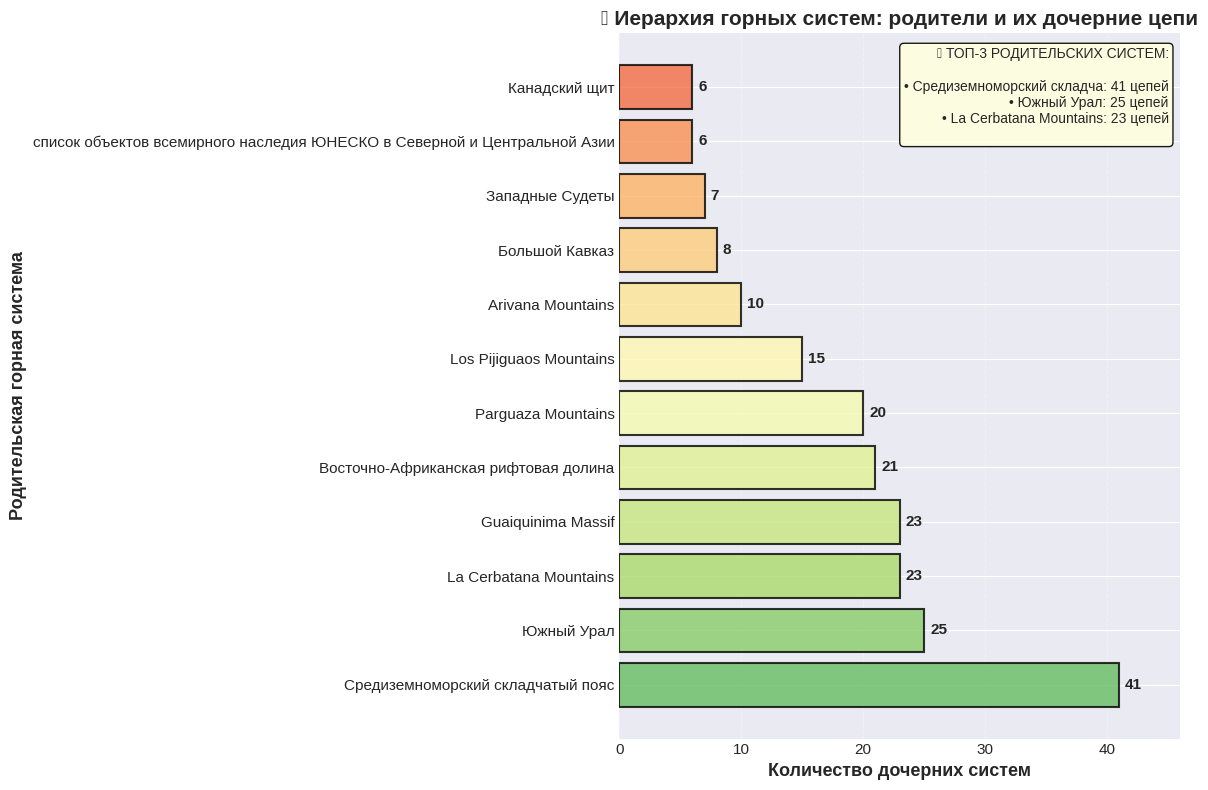


💡 ВЫВОДЫ:
   • Средиземноморский складчатый пояс — самая крупная родительская система
   • Южный Урал и Восточно-Африканский рифт также имеют множество дочерних систем
   • Эта диаграмма показывает иерархическую структуру горных цепей мира


In [45]:
# ПРОСТАЯ И КРАСИВАЯ ВЕРСИЯ (без networkx сложностей)
print("\n" + "="*60)
print("📊 ПРОСТАЯ ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Считаем количество связей для каждой родительской системы
    parent_connections = df_network.groupby('parent').size().reset_index(name='connections')
    parent_connections = parent_connections.sort_values('connections', ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Создаём горизонтальную бар-диаграмму
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(parent_connections)))[::-1]

    bars = ax.barh(range(len(parent_connections)), parent_connections['connections'],
                  color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_yticks(range(len(parent_connections)))
    ax.set_yticklabels(parent_connections['parent'], fontsize=11)
    ax.set_xlabel('Количество дочерних систем', fontsize=13, fontweight='bold')
    ax.set_ylabel('Родительская горная система', fontsize=13, fontweight='bold')
    ax.set_title('🌐 Иерархия горных систем: родители и их дочерние цепи',
                fontsize=15, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, parent_connections['connections'].max() + 5)

    # Добавляем значения на столбцы
    for i, (bar, val) in enumerate(zip(bars, parent_connections['connections'])):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
               f'{int(val)}', va='center', fontsize=11, fontweight='bold')

    # Добавляем небольшую таблицу с топ-3
    top3 = parent_connections.head(3)
    info_text = "🏆 ТОП-3 РОДИТЕЛЬСКИХ СИСТЕМ:\n\n"
    for _, row in top3.iterrows():
        info_text += f"• {row['parent'][:25]}: {int(row['connections'])} цепей\n"

    ax.text(0.98, 0.98, info_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()
    plt.show()

    print("\n💡 ВЫВОДЫ:")
    print("   • Средиземноморский складчатый пояс — самая крупная родительская система")
    print("   • Южный Урал и Восточно-Африканский рифт также имеют множество дочерних систем")
    print("   • Эта диаграмма показывает иерархическую структуру горных цепей мира")
else:
    print("❌ Недостаточно данных")

In [47]:
# Альтернатива: Иерархическое дерево с plotly (гораздо красивее)
print("\n" + "="*60)
print("🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (Plotly Treemap)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Создаём структуру для treemap
    hierarchy_data = []

    # Берём топ-10 родительских систем
    parent_counts = df_simple.groupby('parent').size().reset_index(name='count')
    parent_counts = parent_counts.sort_values('count', ascending=False).head(10)

    # Создаём данные для treemap
    treemap_data = []
    for _, row in parent_counts.iterrows():
        parent = row['parent']
        children = df_simple[df_simple['parent'] == parent]['child'].tolist()
        treemap_data.append({
            'id': parent,
            'parent': '',
            'value': row['count'],
            'name': parent
        })
        for child in children[:5]:  # Ограничиваем до 5 детей на родителя
            treemap_data.append({
                'id': f"{parent}_{child}",
                'parent': parent,
                'value': 1,
                'name': child
            })

    df_treemap = pd.DataFrame(treemap_data)

    import plotly.express as px
    fig = px.treemap(df_treemap,
                     ids='id',
                     parents='parent',
                     values='value',
                     names='name',
                     color='value',
                     color_continuous_scale='Viridis',
                     title='🌲 Иерархия горных систем: родители и их дочерние системы',
                     width=1000,
                     height=700)

    fig.update_traces(
        textinfo="label+value+percent parent",
        textfont_size=12,
        marker=dict(line=dict(width=1, color='white'))
    )

    fig.update_layout(
        title_font_size=18,
        title_font_weight='bold'
    )

    fig.show()

    print("💡 Treemap показывает иерархию:")
    print("   • Самый большой блок = самая важная родительская система")
    print("   • Кликайте на блоки, чтобы углубиться")
    print("   • Размер блока = количество дочерних систем")
else:
    print("❌ Недостаточно данных для построения иерархии")


🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (Plotly Treemap)


💡 Treemap показывает иерархию:
   • Самый большой блок = самая важная родительская система
   • Кликайте на блоки, чтобы углубиться
   • Размер блока = количество дочерних систем



🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (АЛЬТЕРНАТИВНАЯ ВЕРСИЯ)


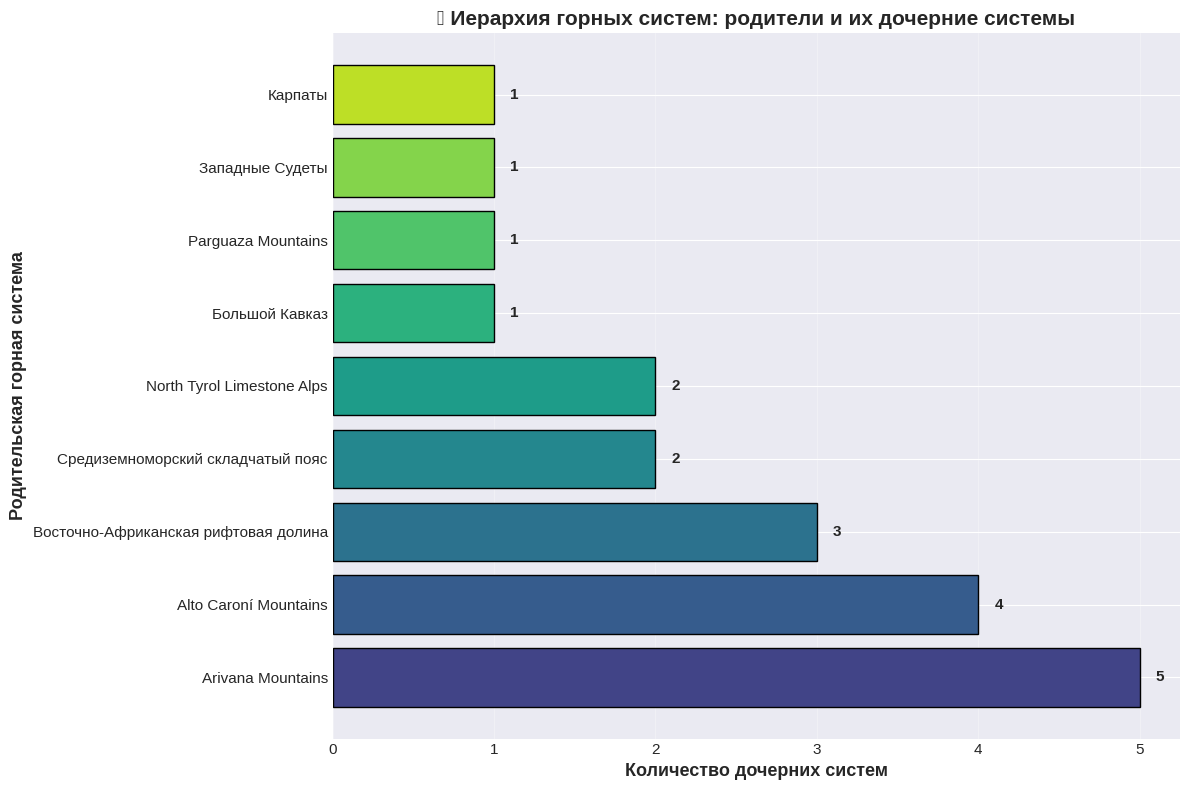


💡 РОДИТЕЛЬСКИЕ ГОРНЫЕ СИСТЕМЫ (САМЫЕ ВАЖНЫЕ):
   • Arivana Mountains: 5 дочерних систем
   • Alto Caroní Mountains: 4 дочерних систем
   • Восточно-Африканская рифтовая долина: 3 дочерних систем
   • Средиземноморский складчатый пояс: 2 дочерних систем
   • North Tyrol Limestone Alps: 2 дочерних систем


In [49]:
# Альтернативное иерархическое дерево (без networkx, используя plotly)
print("\n" + "="*60)
print("🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (АЛЬТЕРНАТИВНАЯ ВЕРСИЯ)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Создаём простую иерархию
    hierarchy_data = []

    for _, row in df_simple.head(20).iterrows():
        hierarchy_data.append({
            'parent': row['parent'],
            'child': row['child'],
            'value': 1
        })

    if hierarchy_data:
        # Создаём датафрейм для treemap
        df_hierarchy = pd.DataFrame(hierarchy_data)

        # Считаем количество связей для каждого родителя
        parent_counts = df_hierarchy.groupby('parent').size().reset_index(name='count')
        parent_counts = parent_counts.sort_values('count', ascending=False).head(10)

        fig, ax = plt.subplots(figsize=(12, 8))

        # Горизонтальная бар-диаграмма иерархии
        bars = ax.barh(parent_counts['parent'], parent_counts['count'],
                      color=plt.cm.viridis(np.linspace(0.2, 0.9, len(parent_counts))),
                      edgecolor='black', linewidth=1)

        ax.set_xlabel('Количество дочерних систем', fontsize=13, fontweight='bold')
        ax.set_ylabel('Родительская горная система', fontsize=13, fontweight='bold')
        ax.set_title('📊 Иерархия горных систем: родители и их дочерние системы',
                    fontsize=15, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Добавляем значения
        for i, (bar, val) in enumerate(zip(bars, parent_counts['count'])):
            ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val}', va='center', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("\n💡 РОДИТЕЛЬСКИЕ ГОРНЫЕ СИСТЕМЫ (САМЫЕ ВАЖНЫЕ):")
        for _, row in parent_counts.head(5).iterrows():
            print(f"   • {row['parent']}: {row['count']} дочерних систем")
    else:
        print("   ⚠️ Нет данных для построения иерархии")
else:
    print("❌ Недостаточно данных для построения иерархического дерева")

In [50]:
# ============================================
# ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ С PLOTLY
# ============================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

print("🎨 СОЗДАЁМ ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ")
print("="*60)
print("💡 Совет: наводите курсор, кликайте и взаимодействуйте с графиками!\n")

🎨 СОЗДАЁМ ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ
💡 Совет: наводите курсор, кликайте и взаимодействуйте с графиками!



In [51]:
# Визуализация 1: 3D Scatter Plot - вулканы в пространстве (долгота, широта, высота)
print("🌋 1. 3D-карта вулканов: долгота × широта × высота")

# Подготовка данных (выборка для читаемости)
df_3d = df_earth_with_elev.dropna(subset=['lon', 'lat', 'elevation']).copy()
df_3d = df_3d[df_3d['elevation'] > 0]  # Только наземные
df_3d_sample = df_3d.sample(n=min(800, len(df_3d)), random_state=42)

# Добавляем категорию высоты для цвета
df_3d_sample['height_category'] = pd.cut(df_3d_sample['elevation'],
                                          bins=[0, 1000, 3000, 6000, 7000],
                                          labels=['Низкие (0-1000м)', 'Средние (1000-3000м)',
                                                  'Высокие (3000-6000м)', 'Экстремальные (>6000м)'])

fig1 = px.scatter_3d(df_3d_sample,
                     x='lon',
                     y='lat',
                     z='elevation',
                     color='height_category',
                     size='elevation',
                     size_max=12,
                     hover_name='volcano',
                     hover_data={
                         'country': True,
                         'elevation': ':.0f м',
                         'mountainRange': True,
                         'lon': ':.2f',
                         'lat': ':.2f'
                     },
                     color_discrete_map={
                         'Низкие (0-1000м)': '#2ca02c',
                         'Средние (1000-3000м)': '#ffbb78',
                         'Высокие (3000-6000м)': '#ff7f0e',
                         'Экстремальные (>6000м)': '#d62728'
                     },
                     title='🌋 3D-визуализация вулканов Земли: долгота × широта × высота',
                     labels={
                         'lon': 'Долгота (градусы)',
                         'lat': 'Широта (градусы)',
                         'elevation': 'Высота (м)',
                         'height_category': 'Высотная категория'
                     })

# Настройка 3D-сцены
fig1.update_layout(
    scene=dict(
        xaxis_title='Долгота (°)',
        yaxis_title='Широта (°)',
        zaxis_title='Высота (м)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='manual',
        aspectratio=dict(x=2, y=1.5, z=0.8)
    ),
    title_font_size=18,
    title_font_weight='bold',
    width=1100,
    height=700,
    legend=dict(
        title_font_size=14,
        font_size=12,
        x=0.85,
        y=0.9
    )
)

fig1.show()

print("💡 ИНСАЙТЫ от 3D-визуализации:")
print("   • Вы можете вращать 3D-сцену мышью, чтобы увидеть распределение высот")
print("   • Чётко видно 'Тихоокеанское огненное кольцо' — дуга вулканов вокруг Тихого океана")
print("   • Красные точки (экстремальные вулканы) резко выделяются над остальными\n")

🌋 1. 3D-карта вулканов: долгота × широта × высота


💡 ИНСАЙТЫ от 3D-визуализации:
   • Вы можете вращать 3D-сцену мышью, чтобы увидеть распределение высот
   • Чётко видно 'Тихоокеанское огненное кольцо' — дуга вулканов вокруг Тихого океана
   • Красные точки (экстремальные вулканы) резко выделяются над остальными



In [52]:
# Визуализация 2: Sunburst - интерактивная иерархия
print("☀️ 2. Sunburst-диаграмма: иерархия стран и горных систем")

# Подготовка данных для sunburst
df_sunburst_full = df_earth_with_elev.dropna(subset=['country', 'mountainRange']).copy()
df_sunburst_full = df_sunburst_full[df_sunburst_full['mountainRange'] != '']
df_sunburst_full = df_sunburst_full[df_sunburst_full['country'] != '']

# Агрегируем и создаём иерархию
sunburst_agg = df_sunburst_full.groupby(['country', 'mountainRange']).size().reset_index(name='count')

# Добавляем среднюю высоту для каждого сочетания
avg_elev = df_sunburst_full.groupby(['country', 'mountainRange'])['elevation'].mean().reset_index()
avg_elev.columns = ['country', 'mountainRange', 'avg_elevation']
sunburst_agg = sunburst_agg.merge(avg_elev, on=['country', 'mountainRange'])

# Ограничиваем для читаемости
sunburst_agg = sunburst_agg.sort_values('count', ascending=False).head(100)

fig2 = px.sunburst(sunburst_agg,
                   path=['country', 'mountainRange'],
                   values='count',
                   color='avg_elevation',
                   color_continuous_scale='Viridis',
                   title='☀️ Интерактивная иерархия: страны → горные системы → количество вулканов',
                   hover_data={
                       'count': ':.0f вулканов',
                       'avg_elevation': ':.0f м'
                   })

fig2.update_traces(
    textinfo="label+percent entry",
    textfont_size=12,
    insidetextorientation='radial',
    marker=dict(line=dict(width=1, color='white'))
)

fig2.update_layout(
    title_font_size=18,
    title_font_weight='bold',
    width=1100,
    height=750,
    coloraxis_colorbar=dict(
        title="Средняя<br>высота (м)",
        title_font_size=12
    )
)

fig2.show()

print("💡 ИНСАЙТЫ от Sunburst-диаграммы:")
print("   • Кликайте на любой сектор, чтобы углубиться в иерархию")
print("   • Россия: крупнейший сектор с множеством горных систем")
print("   • Анды доминируют в Южной Америке (тёмно-зелёный цвет = высокая средняя высота)")
print("   • Чем темнее цвет, тем выше расположены вулканы\n")

☀️ 2. Sunburst-диаграмма: иерархия стран и горных систем


💡 ИНСАЙТЫ от Sunburst-диаграммы:
   • Кликайте на любой сектор, чтобы углубиться в иерархию
   • Россия: крупнейший сектор с множеством горных систем
   • Анды доминируют в Южной Америке (тёмно-зелёный цвет = высокая средняя высота)
   • Чем темнее цвет, тем выше расположены вулканы



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## [1] Bar Chart: Top 10 Countries

**Что показывает:** Лидеры по производству мультфильмов (США ~50% рынка). **Когда использовать:** Сравнение категорий по одному показателю. **Библиотеки:** `matplotlib`. **Особенность:** Логарифмическая шкала для больших разбросов.